# Log-Normal Distribution Fitting via SPY Option Chains

Fits a **2-parameter log-normal law** for the terminal SPY price $S_T$ using call and put mid-prices at three separate DTE horizons:

- **14 DTE** — ~2-week expiry
- **30 DTE** — ~1-month expiry  
- **45 DTE** — ~1.5-month expiry

Each fit uses only options near that expiry (calls **and** puts) and a CVXPY linearized least-squares step to correct the realized (μ, σ) guess toward market prices.

**Section 4** runs a repeated-sample test over historical windows: for a chosen DTE, we sample many chain dates, fit the log-normal, compute the predicted μ and covariance matrix for (underlying, ATM call, ATM put), then compare to the realized outcomes.

---
## 0. Configuration

In [1]:
# ── Change these ──────────────────────────────────────────────────────────────
ASSET = "SPY"

# Chain date to use for Sections 1–3 (fits + distribution plots).
# Must be far enough in the past that we have realized prices:
#   at least 45 calendar days before last available SPY close.
# Set to None to auto-pick (most recent date with ≥45 days of realized data).
CHAIN_DATE = None   # e.g. "2026-01-12"  or None for auto

# DTE targets for the three fits
DTE_14  = 14
DTE_30  = 30
DTE_45  = 45

# Section 4: repeated-sample test
TEST_DTE       = 30          # which DTE distribution to test (14, 30, or 45)
N_SAMPLES      = 60          # how many historical chain dates to sample
MIN_DAYS_BACK  = 50          # chain date must be at least this many calendar days before last close
LOOKBACK_DAYS  = 21          # trading-day window for realized vol / mu guess
N_SCENARIOS    = 50_000      # Monte Carlo draws for predicted distribution
N_PARAM_DRAWS  = 2_000       # parameter-uncertainty draws
R_ANN          = 0.05        # risk-free rate (annualized)

---
## 1. Setup and data load

In [2]:
%matplotlib inline
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.stats import norm, lognorm
from scipy.optimize import brentq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import OPTION_CHAINS_DIR, SPY_DAILY_FILE, RAW_DIR
from data.forecasts import load_chain_for_expiry, _bs_call_price, _bs_put_price

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


In [3]:
# Load SPY price series
price_file = SPY_DAILY_FILE if ASSET == "SPY" else RAW_DIR / f"{ASSET.lower()}_daily.parquet"
prices = pd.read_parquet(price_file)
prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
prices = prices.sort_index()
prices["log_ret"] = np.log(prices["close"] / prices["close"].shift(1))

last_close_date = prices.index.max()
print(f"SPY price range: {prices.index.min().date()} → {last_close_date.date()}")
print(f"Last close: ${prices['close'].iloc[-1]:.2f}")

SPY price range: 2020-01-02 → 2026-02-26
Last close: $689.30


In [4]:
# Discover chain dates and pick the one for fits (must have ≥45 days of realized data)
chain_dir = OPTION_CHAINS_DIR if ASSET == "SPY" else OPTION_CHAINS_DIR / ASSET
all_chain_files = sorted(os.listdir(chain_dir))
chain_dates_all = sorted({
    f.replace("calls_", "").replace("puts_", "").replace(".parquet", "")
    for f in all_chain_files
    if (f.startswith("calls_") or f.startswith("puts_")) and f.endswith(".parquet")
})

MIN_REALIZED_DAYS = 45  # need at least 45 calendar days of realized history
eligible = [
    d for d in chain_dates_all
    if (last_close_date - pd.Timestamp(d)).days >= MIN_REALIZED_DAYS
]

if CHAIN_DATE is not None:
    fit_date = CHAIN_DATE
    assert fit_date in eligible, f"{fit_date} not eligible (need ≥45 days realized data)"
else:
    fit_date = eligible[-1]  # most recent date with ≥45 days of realized data

fit_ts = pd.Timestamp(fit_date)
idx_fit = prices.index.get_indexer([fit_ts], method="ffill")[0]
spot = float(prices.iloc[idx_fit]["close"])

recent_rets = prices.loc[prices.index <= fit_ts, "log_ret"].iloc[-LOOKBACK_DAYS:].dropna()
mu_guess_ann = float(recent_rets.mean() * 252) if len(recent_rets) else 0.0
sigma_guess_ann = .2
#float(recent_rets.std() * np.sqrt(252)) if len(recent_rets) >= 2 else 0.15
sigma_guess_ann = max(sigma_guess_ann, 1e-4)

days_realized = (last_close_date - fit_ts).days
print(f"Fit date (as-of): {fit_date}")
print(f"Spot on fit date: ${spot:.2f}")
print(f"Realized data available: {days_realized} calendar days after fit date")
print(f"Realized guess: mu_ann={mu_guess_ann:+.2%},  sigma_ann={sigma_guess_ann:.2%}")
print(f"Total eligible chain dates: {len(eligible)}")

Fit date (as-of): 2026-01-12
Spot on fit date: $695.16
Realized data available: 45 calendar days after fit date
Realized guess: mu_ann=+13.17%,  sigma_ann=20.00%
Total eligible chain dates: 488


---
## 2. Core helpers: log-normal pricing and fitting

The log-normal model for $S_T$ has two annualized parameters $(\mu_{\text{ann}}, \sigma_{\text{ann}})$:

$$\log S_T \sim \mathcal{N}\!\left(\log S_0 + \left(\mu - \tfrac{1}{2}\sigma^2\right)T,\; \sigma^2 T\right)$$

Options are priced in closed form (Black–Scholes style). We fit $(\mu, \sigma)$ to market mids using one linearized CVXPY least-squares step from the realized guess.

In [5]:
def lognormal_price(K, is_call, mu_ann, sigma_ann, spot_0, T, r=R_ANN):
    """Closed-form log-normal option price (Black-Scholes with arbitrary drift)."""
    sigma_ann = max(float(sigma_ann), 1e-4)
    sigma_t   = max(sigma_ann * np.sqrt(T), 1e-6)
    m  = np.log(spot_0) + (float(mu_ann) - 0.5 * sigma_ann**2) * T
    d2 = (m - np.log(K)) / sigma_t
    d1 = d2 + sigma_t
    mean_st = np.exp(m + 0.5 * sigma_t**2)
    if is_call:
        payoff = mean_st * norm.cdf(d1) - K * norm.cdf(d2)
    else:
        payoff = K * norm.cdf(-d2) - mean_st * norm.cdf(-d1)
    return np.exp(-r * T) * payoff


def lognormal_price_vec(df, mu_ann, sigma_ann, spot_0, T, r=R_ANN):
    """Price a DataFrame of options (columns: strike, type) under log-normal."""
    return np.array([
        lognormal_price(row["strike"], row["type"] == "call",
                        mu_ann, sigma_ann, spot_0, T, r)
        for _, row in df.iterrows()
    ])


def fit_lognormal(option_df, spot_0, T, r=R_ANN,
                  mu_guess=None, sigma_guess=None,
                  recent_log_rets=None):
    """
    Fit (mu_ann, sigma_ann) to option_df market mids via one linearized CVXPY QP step.

    Returns dict with keys: mu_guess, sigma_guess, mu_fit, sigma_fit,
                            param_cov, train_rmse, holdout_rmse, option_df.
    """
    if mu_guess is None:
        mu_guess = float(recent_log_rets.mean() * 252) if recent_log_rets is not None and len(recent_log_rets) else 0.0
    if sigma_guess is None:
        sigma_guess = max(float(recent_log_rets.std() * np.sqrt(252)) if recent_log_rets is not None and len(recent_log_rets) >= 2 else 0.15, 1e-4)

    df = option_df.sort_values(["type", "strike"]).reset_index(drop=True).copy()
    holdout_mask = (np.arange(len(df)) % 5) == 0
    train_df = df.loc[~holdout_mask]

    bump_mu    = max(0.01, 0.25 * max(abs(mu_guess), 0.01))
    bump_sigma = max(0.01, 0.10 * sigma_guess)

    base  = lognormal_price_vec(train_df, mu_guess, sigma_guess, spot_0, T, r)
    jac   = np.column_stack([
        (lognormal_price_vec(train_df, mu_guess + bump_mu, sigma_guess, spot_0, T, r) - base) / bump_mu,
        (lognormal_price_vec(train_df, mu_guess, sigma_guess + bump_sigma, spot_0, T, r) - base) / bump_sigma,
    ])

    step = cp.Variable(2)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(base + jac @ step - train_df["market_mid"].to_numpy())),
        [sigma_guess + step[1] >= 0.02]
    )
    prob.solve()
    sv = np.zeros(2) if step.value is None else np.asarray(step.value).reshape(-1)

    mu_fit    = mu_guess    + float(sv[0])
    sigma_fit = max(0.02,  sigma_guess + float(sv[1]))

    df["guess_price"] = lognormal_price_vec(df, mu_guess, sigma_guess, spot_0, T, r)
    df["fit_price"]   = lognormal_price_vec(df, mu_fit,   sigma_fit,   spot_0, T, r)

    def rmse(mask, col):
        return float(np.sqrt(((df.loc[mask, col] - df.loc[mask, "market_mid"]) ** 2).mean()))

    # Local parameter covariance (for sampling uncertainty)
    base_fit  = lognormal_price_vec(train_df, mu_fit, sigma_fit, spot_0, T, r)
    bm_f = max(0.01, 0.25 * max(abs(mu_fit), 0.01))
    bs_f = max(0.01, 0.10 * sigma_fit)
    jac_fit = np.column_stack([
        (lognormal_price_vec(train_df, mu_fit + bm_f, sigma_fit, spot_0, T, r) - base_fit) / bm_f,
        (lognormal_price_vec(train_df, mu_fit, sigma_fit + bs_f, spot_0, T, r) - base_fit) / bs_f,
    ])
    resid = train_df["market_mid"].to_numpy() - base_fit
    dof   = max(len(train_df) - 2, 1)
    mse   = float(np.sum(resid**2) / dof)
    param_cov = mse * np.linalg.pinv(jac_fit.T @ jac_fit)
    param_cov = np.nan_to_num(0.5 * (param_cov + param_cov.T), nan=0.0, posinf=0.0, neginf=0.0)

    return dict(
        mu_guess=mu_guess, sigma_guess=sigma_guess,
        mu_fit=mu_fit,     sigma_fit=sigma_fit,
        param_cov=param_cov,
        train_rmse_guess=rmse(~holdout_mask, "guess_price"),
        train_rmse_fit=rmse(~holdout_mask, "fit_price"),
        holdout_rmse_guess=rmse(holdout_mask, "guess_price"),
        holdout_rmse_fit=rmse(holdout_mask, "fit_price"),
        option_df=df, T=T, r=r, spot=spot_0,
    )


def to_per_share(mid, K, spot_0, is_call, r, T, tol=0.01):
    """Return per-share option mid, or NaN if bounds fail."""
    mid = float(mid)
    if not np.isfinite(mid) or mid <= 0:
        return np.nan
    if is_call:
        lb, ub = 0.0, spot_0
    else:
        lb, ub = max(0.0, K - spot_0), K * np.exp(-r * T)
    if lb - tol <= mid <= ub + tol:
        return mid
    if mid > 5.0 * ub and ub > 0:
        candidate = mid / 100.0
        if lb - tol <= candidate <= ub + tol:
            return candidate
    return np.nan


def load_options_for_dte(chain_date, target_dte, spot_0, r=R_ANN, min_mid=0.02, max_spread=0.80):
    """
    Load calls + puts closest to target_dte, filter to valid per-share mids.
    Returns (option_df, expiry_str, T).
    """
    ref = pd.Timestamp(chain_date)
    meta = pd.read_parquet(chain_dir / f"calls_{chain_date}.parquet")
    meta.columns = [c.replace("impliedVolatility", "impl_vol").lower() for c in meta.columns]
    expiry_arg = None
    if "expiry" in meta.columns:
        expiries  = sorted(meta["expiry"].dropna().unique())
        dte_list  = [(e, (pd.Timestamp(e) - ref).days) for e in expiries
                     if (pd.Timestamp(e) - ref).days > 0]
        if dte_list:
            expiry_arg = min(dte_list, key=lambda x: abs(x[1] - target_dte))[0]

    calls, puts, expiry_used = load_chain_for_expiry(
        chain_date=chain_date, expiry=expiry_arg, underlying=ASSET,
        min_mid=min_mid, max_spread=max_spread,
    )
    if len(calls) == 0 or len(puts) == 0:
        raise ValueError(f"No valid calls/puts on {chain_date} near DTE {target_dte}")

    exp_ts = pd.Timestamp(expiry_used)
    T      = max((exp_ts - ref).days / 365.0, 1e-4)

    rows = []
    for is_call, df_src in [(True, calls), (False, puts)]:
        for _, row in df_src.iterrows():
            K   = float(row["strike"])
            raw = float(row.get("mid", (row.get("bid", 0.0) + row.get("ask", 0.0)) / 2.0))
            mid = to_per_share(raw, K, spot_0, is_call, r, T)
            if np.isfinite(mid):
                rows.append({"strike": K, "type": "call" if is_call else "put", "market_mid": mid})

    if len(rows) < 10:
        raise ValueError(f"Too few valid options after filter on {chain_date} DTE~{target_dte}")

    return pd.DataFrame(rows), expiry_used, T


# ── ATM implied-vol baseline ─────────────────────────────────────────────────

def _bs_call(S, K, T, r, sigma):
    """Standard Black-Scholes call price (risk-neutral drift = r)."""
    sigma = max(sigma, 1e-6)
    sqrt_T = max(np.sqrt(T), 1e-6)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def compute_atm_iv(option_df, spot_0, T, r=R_ANN, iv_lo=1e-4, iv_hi=5.0):
    """
    Compute ATM implied volatility from the option chain.

    Strategy:
      1. Find the call whose strike is closest to spot_0.
      2. Invert Black-Scholes (risk-neutral, drift = r) using Brent's method.
      3. If inversion fails, fall back to the median IV across all OTM calls.

    Returns (sigma_iv, strike_used).
    """
    calls = option_df[option_df["type"] == "call"].copy()
    if calls.empty:
        raise ValueError("No calls in option_df for IV computation.")

    calls = calls.assign(_dist=(calls["strike"] - spot_0).abs())
    atm_row = calls.loc[calls["_dist"].idxmin()]
    K_atm = float(atm_row["strike"])
    mid   = float(atm_row["market_mid"])

    def objective(sig):
        return _bs_call(spot_0, K_atm, T, r, sig) - mid

    try:
        lo_val, hi_val = objective(iv_lo), objective(iv_hi)
        if lo_val * hi_val > 0:
            # Bracket not valid — fall back to median across all calls
            ivs = []
            for _, row in calls.iterrows():
                try:
                    iv = brentq(
                        lambda s: _bs_call(spot_0, row["strike"], T, r, s) - row["market_mid"],
                        iv_lo, iv_hi, xtol=1e-6
                    )
                    ivs.append(iv)
                except Exception:
                    pass
            if not ivs:
                raise ValueError("IV inversion failed on all calls.")
            return float(np.median(ivs)), K_atm

        sigma_iv = brentq(objective, iv_lo, iv_hi, xtol=1e-6)
        return float(sigma_iv), K_atm
    except Exception as e:
        raise ValueError(f"ATM IV inversion failed (K={K_atm:.1f}, mid={mid:.4f}): {e}")


def iv_lognormal_pdf(S_grid, spot_0, sigma_iv, T, r=R_ANN):
    """Log-normal PDF under risk-neutral measure using σ = ATM IV, drift = r."""
    sig_t = max(sigma_iv * np.sqrt(T), 1e-6)
    m     = np.log(spot_0) + (r - 0.5 * sigma_iv**2) * T
    return lognorm.pdf(S_grid, s=sig_t, scale=np.exp(m))


print("Helpers defined.")

Helpers defined.


---
## 2b. Gauss-Newton / DNLP Fitting via Iterative CVXPY QP Subproblems

The original `fit_lognormal` linearizes the pricing map **once** from the realized-vol guess — a single Newton step. That works well only when the guess is close to the market-implied optimum.

**Gauss-Newton (GN)** iterates this idea: at each step we linearize around the *current* estimate, solve a constrained CVXPY quadratic programme, then update. This turns the non-convex nonlinear least-squares problem into a sequence of **disciplined convex QPs** — a principled *Disciplined Non-Linear Programming (DNLP)* decomposition:

$$
\underbrace{\min_{\mu,\sigma}\; \tfrac{1}{2}\sum_i \bigl[p_i(\mu,\sigma) - m_i\bigr]^2}_{\text{nonlinear NLS}}
\;\;\Longrightarrow\;\;
\underbrace{\min_{\delta}\; \tfrac{1}{2}\|r^{(k)} + J^{(k)}\delta\|^2 + \tfrac{\lambda}{2}\|\delta\|^2}_{\text{convex CVXPY QP at iteration }k}
$$

The Levenberg-Marquardt damping term $\frac{\lambda}{2}\|\delta\|^2$ ensures each QP has a unique solution and automatically interpolates between gradient descent (large $\lambda$) and pure GN (small $\lambda$).  $\lambda$ is reduced each iteration as the residual improves (trust-region-style adaptive damping).

In [6]:
def _numerical_jacobian(df, mu, sigma, spot_0, T, r):
    """Numerical Jacobian of lognormal_price_vec w.r.t. (mu, sigma)."""
    h_mu    = max(1e-4, 0.01 * max(abs(mu), 0.01))
    h_sigma = max(1e-4, 0.01 * sigma)
    base = lognormal_price_vec(df, mu, sigma, spot_0, T, r)
    d_mu    = (lognormal_price_vec(df, mu + h_mu,    sigma,         spot_0, T, r) - base) / h_mu
    d_sigma = (lognormal_price_vec(df, mu,           sigma + h_sigma, spot_0, T, r) - base) / h_sigma
    return np.column_stack([d_mu, d_sigma]), base


def fit_lognormal_gn(option_df, spot_0, T, r=R_ANN,
                     mu_guess=None, sigma_guess=None,
                     recent_log_rets=None,
                     max_iter=25, tol=1e-7,
                     lm_lambda_init=1e-2, lm_shrink=0.5, lm_grow=2.0):
    """
    Gauss-Newton (Levenberg-Marquardt) iterative log-normal fit.

    Each iteration solves a CVXPY QP subproblem:
        min  ||r + J*delta||^2 + lambda * ||delta||^2
        s.t. sigma + delta_sigma >= 0.02

    lambda adapts: shrinks when residual improves, grows when it doesn't.
    Returns same dict as fit_lognormal plus 'gn_history' (list of per-iter stats).
    """
    if mu_guess is None:
        mu_guess = float(recent_log_rets.mean() * 252) if recent_log_rets is not None and len(recent_log_rets) else 0.0
    if sigma_guess is None:
        sigma_guess = max(float(recent_log_rets.std() * np.sqrt(252)) if recent_log_rets is not None and len(recent_log_rets) >= 2 else 0.15, 1e-4)

    df = option_df.sort_values(["type", "strike"]).reset_index(drop=True).copy()
    holdout_mask = (np.arange(len(df)) % 5) == 0
    train_df     = df.loc[~holdout_mask].reset_index(drop=True)
    mids_train   = train_df["market_mid"].to_numpy()

    mu    = float(mu_guess)
    sigma = max(float(sigma_guess), 0.02)
    lam   = lm_lambda_init

    history = []
    prev_sse = np.inf

    for it in range(max_iter):
        J, prices_cur = _numerical_jacobian(train_df, mu, sigma, spot_0, T, r)
        residuals = mids_train - prices_cur
        sse_cur   = float(np.dot(residuals, residuals))

        history.append({"iter": it, "mu": mu, "sigma": sigma,
                         "sse": sse_cur, "lambda": lam})

        # ── CVXPY QP subproblem (DNLP step) ──────────────────────────────────
        delta = cp.Variable(2)
        lm_reg = lam * cp.sum_squares(delta)          # Levenberg-Marquardt damping
        objective  = cp.Minimize(cp.sum_squares(residuals - J @ delta) + lm_reg)
        constraint = [sigma + delta[1] >= 0.02]
        cp.Problem(objective, constraint).solve(warm_start=True)

        if delta.value is None:                        # solver failed; bail out
            break

        dv = np.asarray(delta.value).reshape(-1)
        mu_new    = mu    + float(dv[0])
        sigma_new = max(0.02, sigma + float(dv[1]))

        _, prices_new = _numerical_jacobian(train_df, mu_new, sigma_new, spot_0, T, r)
        sse_new = float(np.sum((mids_train - prices_new) ** 2))

        if sse_new < sse_cur:
            # Accept step and reduce damping (more Newton-like)
            mu, sigma = mu_new, sigma_new
            lam = max(lam * lm_shrink, 1e-8)
            if abs(sse_cur - sse_new) / max(sse_cur, 1e-12) < tol:
                break
        else:
            # Reject step; increase damping (more gradient-descent-like)
            lam = min(lam * lm_grow, 1e3)

        prev_sse = sse_cur

    # ── Final annotation of full DataFrame ───────────────────────────────────
    df["guess_price"] = lognormal_price_vec(df, mu_guess, sigma_guess, spot_0, T, r)
    df["fit_price_1step"] = lognormal_price_vec(df, *[
        v for v in [mu_guess, sigma_guess]    # reuse single-step for comparison
    ], spot_0, T, r)
    df["fit_price_gn"] = lognormal_price_vec(df, mu, sigma, spot_0, T, r)

    def rmse(mask, col):
        return float(np.sqrt(((df.loc[mask, col] - df.loc[mask, "market_mid"]) ** 2).mean()))

    # Parameter covariance at converged point
    J_final, prices_final = _numerical_jacobian(train_df, mu, sigma, spot_0, T, r)
    resid_final = mids_train - prices_final
    dof         = max(len(train_df) - 2, 1)
    mse_final   = float(np.dot(resid_final, resid_final) / dof)
    JTJ         = J_final.T @ J_final
    param_cov   = mse_final * np.linalg.pinv(JTJ)
    param_cov   = np.nan_to_num(0.5 * (param_cov + param_cov.T),
                                nan=0.0, posinf=0.0, neginf=0.0)

    n_iter = len(history)
    print(f"  GN converged in {n_iter} iterations  "
          f"μ={mu:+.4f}  σ={sigma:.4f}  "
          f"train RMSE={rmse(~holdout_mask, 'fit_price_gn'):.4f}  "
          f"holdout RMSE={rmse(holdout_mask, 'fit_price_gn'):.4f}")

    return dict(
        mu_guess=mu_guess, sigma_guess=sigma_guess,
        mu_fit=mu,         sigma_fit=sigma,
        param_cov=param_cov,
        train_rmse_guess   =rmse(~holdout_mask, "guess_price"),
        train_rmse_fit     =rmse(~holdout_mask, "fit_price_gn"),
        holdout_rmse_guess =rmse( holdout_mask, "guess_price"),
        holdout_rmse_fit   =rmse( holdout_mask, "fit_price_gn"),
        option_df=df, T=T, r=r, spot=spot_0,
        gn_history=history,
    )


print("Gauss-Newton / DNLP fitter defined.")

Gauss-Newton / DNLP fitter defined.


---
## 3. Fit log-normal at 14 DTE, 30 DTE, and 45 DTE

For each DTE we:
1. Select the expiry closest to the target DTE from the chain on `fit_date`.
2. Filter calls and puts to valid per-share mid-prices.
3. Fit (μ_ann, σ_ann) via one linearized CVXPY least-squares step.
4. Report train / holdout RMSE and visualize the distribution and pricing error.

In [7]:
# ── Shared color palette (used by all plot cells) ────────────────────────────
COLORS = {"14d": "#2563eb", "30d": "#16a34a", "45d": "#dc2626"}

# ── Fit all three horizons ──────────────────────────────────────────────────
fits = {}
for label, target_dte in [("14d", DTE_14), ("30d", DTE_30), ("45d", DTE_45)]:
    try:
        opt_df, expiry_str, T_dte = load_options_for_dte(
            fit_date, target_dte, spot, r=R_ANN
        )
        result = fit_lognormal(
            opt_df, spot, T_dte, r=R_ANN,
            mu_guess=mu_guess_ann, sigma_guess=sigma_guess_ann,
        )
        result["expiry"] = expiry_str
        result["actual_dte"] = round(T_dte * 365)
        result["label"] = label
        fits[label] = result
        print(f"[{label}]  expiry={expiry_str}  DTE={result['actual_dte']}  "
              f"n_opts={len(opt_df)}")
        print(f"  Guess:  mu={result['mu_guess']:+.2%}  sigma={result['sigma_guess']:.2%}")
        print(f"  Fitted: mu={result['mu_fit']:+.2%}  sigma={result['sigma_fit']:.2%}")
        print(f"  RMSE  train  guess={result['train_rmse_guess']:.4f}  "
              f"fit={result['train_rmse_fit']:.4f}")
        print(f"  RMSE holdout guess={result['holdout_rmse_guess']:.4f}  "
              f"fit={result['holdout_rmse_fit']:.4f}")
        print()
    except Exception as e:
        print(f"[{label}] FAILED: {e}")

[14d]  expiry=2026-01-26  DTE=14  n_opts=34
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+5.63%  sigma=11.80%
  RMSE  train  guess=3.5619  fit=0.6586
  RMSE holdout guess=3.4252  fit=0.5346

[30d]  expiry=2026-02-13  DTE=32  n_opts=146
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+4.29%  sigma=13.63%
  RMSE  train  guess=5.5401  fit=1.1160
  RMSE holdout guess=5.7219  fit=1.2748

[45d]  expiry=2026-02-27  DTE=46  n_opts=225
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+4.12%  sigma=14.30%
  RMSE  train  guess=6.5266  fit=1.5344
  RMSE holdout guess=6.5584  fit=1.5649



### 3.1 Individual distribution + pricing-error plots

In [8]:
# # One 2-panel figure per DTE: (left) PDF of S_T, (right) model vs market mid
# COLORS = {"14d": "#2563eb", "30d": "#16a34a", "45d": "#dc2626"}

# for label, res in fits.items():
#     df_plot = res["option_df"]
#     T_  = res["T"]
#     s0  = res["spot"]

#     def _ln_params(mu_a, sig_a):
#         sig_t  = max(sig_a * np.sqrt(T_), 1e-6)
#         m      = np.log(s0) + (mu_a - 0.5 * sig_a**2) * T_
#         return sig_t, np.exp(m)

#     sg, sc = _ln_params(res["mu_guess"], res["sigma_guess"])
#     sf, scf = _ln_params(res["mu_fit"],   res["sigma_fit"])
#     S_grid = np.linspace(s0 * 0.70, s0 * 1.30, 600)

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     col = COLORS[label]

#     # Left: terminal distribution
#     ax = axes[0]
#     ax.plot(S_grid, lognorm.pdf(S_grid, s=sg, scale=sc),
#             ls="--", lw=1.5, color="gray", label="Guess")
#     ax.plot(S_grid, lognorm.pdf(S_grid, s=sf, scale=scf),
#             lw=2.5, color=col, label="Fit")
#     ax.axvline(s0, color="black", ls=":", alpha=0.6, label=f"Spot={s0:.0f}")
#     ax.set_title(f"[{label}] Terminal $S_T$ distribution  (expiry {res['expiry']})")
#     ax.set_xlabel("$S_T$"); ax.set_ylabel("Density")
#     ax.legend(fontsize=9)

#     # Middle: model vs market (calls)
#     ax = axes[1]
#     for opt_type, marker, ec in [("call", "o", "#16a34a"), ("put", "^", "#dc2626")]:
#         sub = df_plot[df_plot["type"] == opt_type].sort_values("strike")
#         ax.scatter(sub["strike"], sub["market_mid"],
#                    s=14, color="black", marker=marker, zorder=3, alpha=0.7,
#                    label=f"Mkt {opt_type}" if opt_type == "call" else None)
#         ax.scatter(sub["strike"], sub["guess_price"],
#                    s=8, color="gray", marker=marker, alpha=0.4)
#         ax.scatter(sub["strike"], sub["fit_price"],
#                    s=8, color=col, marker=marker, alpha=0.6,
#                    label=f"Fit {opt_type}" if opt_type == "call" else None)
#     ax.axvline(s0, color="black", ls=":", alpha=0.5)
#     ax.set_title(f"[{label}] Model vs market mid ({len(df_plot)} options)")
#     ax.set_xlabel("Strike"); ax.set_ylabel("Option price")
#     ax.legend(fontsize=9)

#     # Right: error vs moneyness
#     ax = axes[2]
#     df_plot = df_plot.copy()
#     df_plot["error"]     = df_plot["fit_price"] - df_plot["market_mid"]
#     df_plot["moneyness"] = df_plot["strike"] / s0
#     for opt_type, ec in [("call", "#16a34a"), ("put", "#dc2626")]:
#         sub = df_plot[df_plot["type"] == opt_type]
#         ax.scatter(sub["moneyness"], sub["error"],
#                    s=20, color=ec, alpha=0.7, label=opt_type)
#     ax.axhline(0, color="black", ls="--", lw=1)
#     ax.set_title(f"[{label}] Pricing error vs moneyness")
#     ax.set_xlabel("Strike / Spot"); ax.set_ylabel("Fit price − Mkt mid ($)")
#     ax.legend(fontsize=9)

#     plt.tight_layout()
#     plt.show()

### 3.2 Overlay: all three fitted distributions

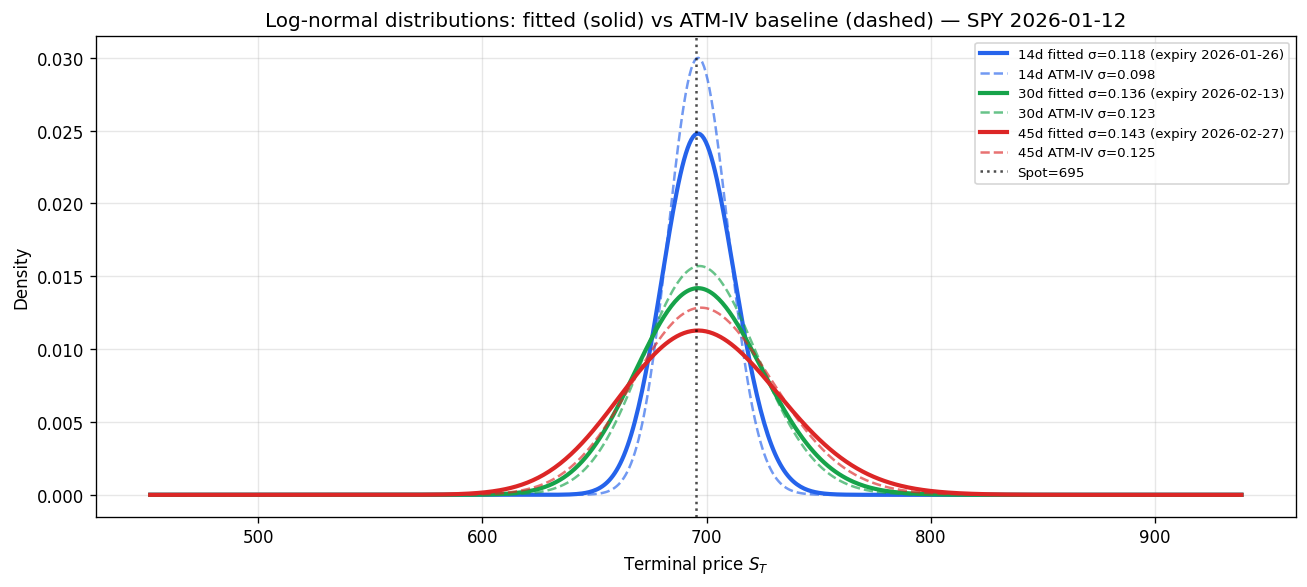

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))

iv_cache = {}   # store ATM IVs for later use in section 3.5
_gn = globals().get('fits_gn', {})   # safe: may not exist yet on first run

for label, res in fits.items():
    T_  = res["T"]
    s0  = res["spot"]
    S_grid = np.linspace(s0 * 0.65, s0 * 1.35, 600)
    color  = COLORS[label]

    # ── Fitted log-normal (GN if available, else single-step) ──────────────
    mu_plot    = _gn[label]["mu_fit"]    if label in _gn else res["mu_fit"]
    sigma_plot = _gn[label]["sigma_fit"] if label in _gn else res["sigma_fit"]
    sig_t = max(sigma_plot * np.sqrt(T_), 1e-6)
    m     = np.log(s0) + (mu_plot - 0.5 * sigma_plot**2) * T_
    pdf_fit = lognorm.pdf(S_grid, s=sig_t, scale=np.exp(m))
    ax.plot(S_grid, pdf_fit, lw=2.5, color=color,
            label=f"{label} fitted σ={sigma_plot:.3f} (expiry {res['expiry']})")

    # ── ATM-IV baseline: risk-neutral log-normal with σ = ATM IV ───────────
    try:
        sigma_iv, K_atm = compute_atm_iv(res["option_df"], s0, T_, r=R_ANN)
        iv_cache[label] = {"sigma_iv": sigma_iv, "K_atm": K_atm, "T": T_, "spot": s0,
                           "expiry": res["expiry"]}
        pdf_iv = iv_lognormal_pdf(S_grid, s0, sigma_iv, T_, r=R_ANN)
        ax.plot(S_grid, pdf_iv, lw=1.5, color=color, ls="--", alpha=0.65,
                label=f"{label} ATM-IV σ={sigma_iv:.3f}")
    except Exception as e:
        print(f"  [{label}] ATM IV failed: {e}")

ax.axvline(spot, color="black", ls=":", lw=1.5, alpha=0.7, label=f"Spot={spot:.0f}")
ax.set_xlabel("Terminal price $S_T$")
ax.set_ylabel("Density")
ax.set_title(f"Log-normal distributions: fitted (solid) vs ATM-IV baseline (dashed) — {ASSET} {fit_date}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Gauss-Newton (DNLP) fit — all three DTE horizons

Run `fit_lognormal_gn` for each horizon and compare the holdout RMSE to the single linearized step.

In [10]:
fits_gn = {}
for label, target_dte in [("14d", DTE_14), ("30d", DTE_30), ("45d", DTE_45)]:
    try:
        opt_df, expiry_str, T = load_options_for_dte(
            fit_date, target_dte, spot, r=R_ANN
        )
        print(f"\n── {label}  expiry={expiry_str}  T={T:.4f}yr  n_options={len(opt_df)} ──")
        res = fit_lognormal_gn(
            opt_df, spot_0=spot, T=T, r=R_ANN,
            mu_guess=mu_guess_ann, sigma_guess=sigma_guess_ann,
            recent_log_rets=recent_rets,
        )
        fits_gn[label] = res
        fits_gn[label]["expiry"] = expiry_str

        # Cross-compare with single-step
        res_1step = fits[label]
        print(f"  1-step  holdout RMSE = {res_1step['holdout_rmse_fit']:.4f}   "
              f"μ={res_1step['mu_fit']:+.4f}  σ={res_1step['sigma_fit']:.4f}")
        improvement = (res_1step['holdout_rmse_fit'] - res['holdout_rmse_fit'])
        pct = 100 * improvement / max(res_1step['holdout_rmse_fit'], 1e-9)
        print(f"  GN      holdout RMSE = {res['holdout_rmse_fit']:.4f}   "
              f"μ={res['mu_fit']:+.4f}  σ={res['sigma_fit']:.4f}  "
              f"  Δ = {improvement:+.4f} ({pct:+.1f}%)")
    except Exception as e:
        print(f"{label}: {e}")


── 14d  expiry=2026-01-26  T=0.0384yr  n_options=34 ──
  GN converged in 6 iterations  μ=+0.0581  σ=0.1017  train RMSE=0.4581  holdout RMSE=0.3316
  1-step  holdout RMSE = 0.5346   μ=+0.0563  σ=0.1180
  GN      holdout RMSE = 0.3316   μ=+0.0581  σ=0.1017    Δ = +0.2030 (+38.0%)

── 30d  expiry=2026-02-13  T=0.0877yr  n_options=146 ──
  GN converged in 6 iterations  μ=+0.0462  σ=0.1296  train RMSE=1.0499  holdout RMSE=1.2740
  1-step  holdout RMSE = 1.2748   μ=+0.0429  σ=0.1363
  GN      holdout RMSE = 1.2740   μ=+0.0462  σ=0.1296    Δ = +0.0008 (+0.1%)

── 45d  expiry=2026-02-27  T=0.1260yr  n_options=225 ──
  GN converged in 6 iterations  μ=+0.0439  σ=0.1339  train RMSE=1.4381  holdout RMSE=1.4892
  1-step  holdout RMSE = 1.5649   μ=+0.0412  σ=0.1430
  GN      holdout RMSE = 1.4892   μ=+0.0439  σ=0.1339    Δ = +0.0757 (+4.8%)


### 3.4 GN convergence trajectories and final fit quality

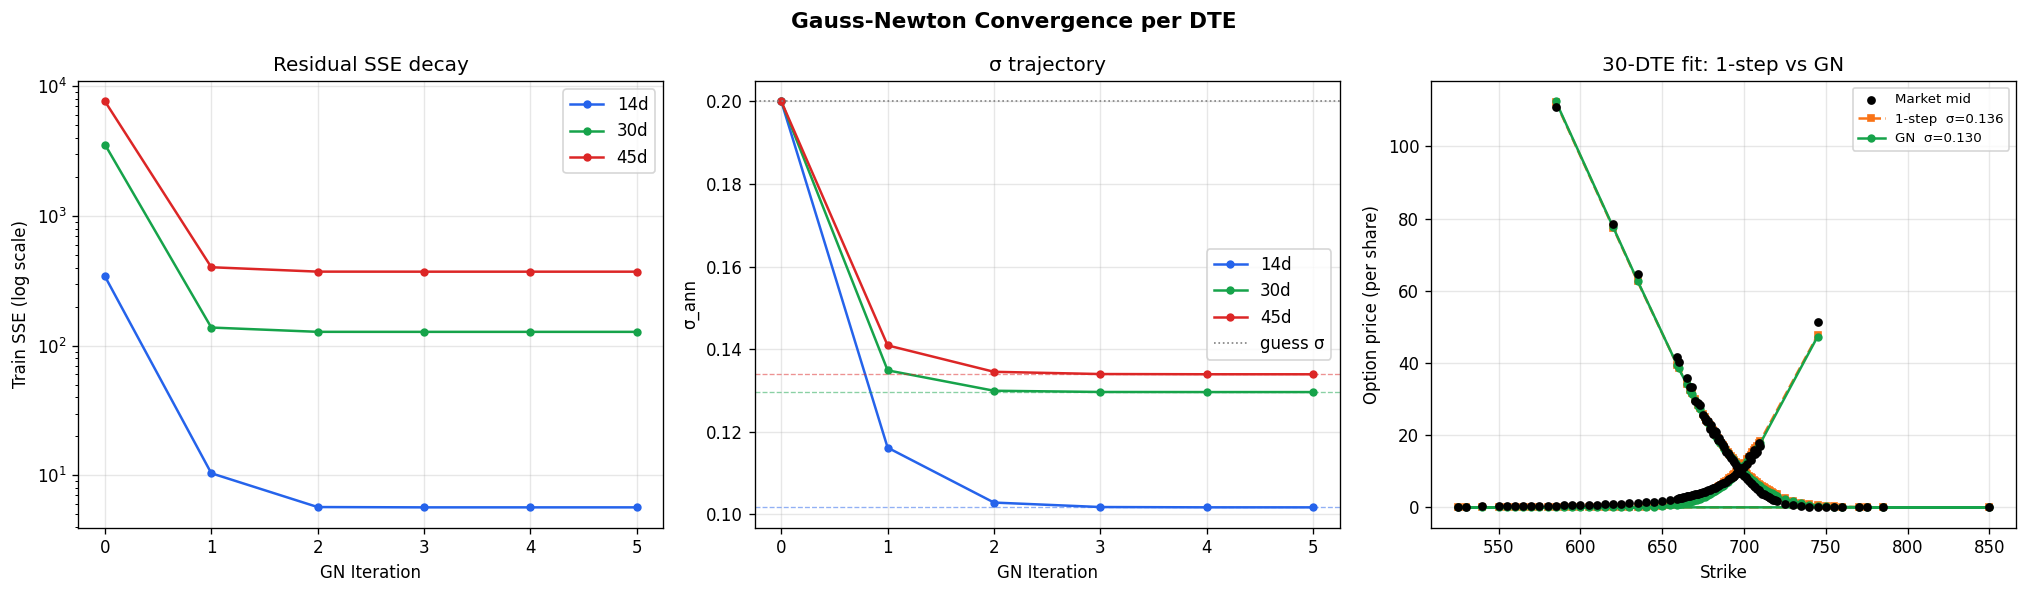


─── Holdout RMSE comparison ───────────────────────────────────────
DTE      1-step RMSE    GN RMSE     Δ RMSE  n_iter
----------------------------------------------------
14d           0.5346     0.3316    +0.2030       6
30d           1.2748     1.2740    +0.0008       6
45d           1.5649     1.4892    +0.0757       6


In [11]:
if not fits_gn:
    print("No GN fits available — run the cell above first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Gauss-Newton Convergence per DTE", fontsize=13, fontweight="bold")

    # ── Left: SSE decay ──────────────────────────────────────────────────────
    ax = axes[0]
    for label, res in fits_gn.items():
        hist = res["gn_history"]
        iters = [h["iter"] for h in hist]
        sses  = [h["sse"]  for h in hist]
        ax.semilogy(iters, sses, marker="o", ms=4, color=COLORS[label], label=label)
    ax.set_xlabel("GN Iteration")
    ax.set_ylabel("Train SSE (log scale)")
    ax.set_title("Residual SSE decay")
    ax.legend()

    # ── Middle: σ trajectory ─────────────────────────────────────────────────
    ax = axes[1]
    for label, res in fits_gn.items():
        hist = res["gn_history"]
        iters  = [h["iter"]  for h in hist]
        sigmas = [h["sigma"] for h in hist]
        ax.plot(iters, sigmas, marker="o", ms=4, color=COLORS[label], label=label)
        ax.axhline(res["sigma_fit"], ls="--", lw=0.8, color=COLORS[label], alpha=0.5)
    ax.axhline(sigma_guess_ann, ls=":", lw=1, color="gray", label="guess σ")
    ax.set_xlabel("GN Iteration")
    ax.set_ylabel("σ_ann")
    ax.set_title("σ trajectory")
    ax.legend()

    # ── Right: 1-step vs GN final fit, market mid scatter for TEST_DTE ───────
    ax = axes[2]
    key = f"{TEST_DTE}d"
    if key in fits_gn and key in fits:
        res_gn = fits_gn[key]
        res_1s = fits[key]
        df_gn  = res_gn["option_df"]
        strikes = df_gn["strike"].values
        mids    = df_gn["market_mid"].values

        ax.scatter(strikes, mids, s=18, color="black", zorder=3, label="Market mid")
        ax.plot(strikes, lognormal_price_vec(df_gn, res_1s["mu_fit"],  res_1s["sigma_fit"],  spot, res_gn["T"]),
                "s--", ms=4, color="#f97316", label=f"1-step  σ={res_1s['sigma_fit']:.3f}")
        ax.plot(strikes, lognormal_price_vec(df_gn, res_gn["mu_fit"],  res_gn["sigma_fit"],  spot, res_gn["T"]),
                "o-",  ms=4, color=COLORS.get(key, "#6366f1"), label=f"GN  σ={res_gn['sigma_fit']:.3f}")
        ax.set_xlabel("Strike")
        ax.set_ylabel("Option price (per share)")
        ax.set_title(f"{TEST_DTE}-DTE fit: 1-step vs GN")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f"No {TEST_DTE}d fit", ha="center", va="center",
                transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n─── Holdout RMSE comparison ───────────────────────────────────────")
    print(f"{'DTE':<6} {'1-step RMSE':>13} {'GN RMSE':>10} {'Δ RMSE':>10} {'n_iter':>7}")
    print("-" * 52)
    for label in ["14d", "30d", "45d"]:
        if label not in fits_gn or label not in fits:
            continue
        r1  = fits[label]["holdout_rmse_fit"]
        rgn = fits_gn[label]["holdout_rmse_fit"]
        ni  = len(fits_gn[label]["gn_history"])
        print(f"{label:<6} {r1:>13.4f} {rgn:>10.4f} {r1-rgn:>+10.4f} {ni:>7d}")

### 3.5 GN-fit vs ATM-IV baseline: residuals and distribution gap

Three-panel per DTE:
- **Left** — per-option pricing residuals: GN-fit (filled bars) vs ATM-IV model (outline bars).  Smaller residuals = better calibration to the full smile.
- **Center** — PDF overlay for the chosen DTE: GN-fit (solid) vs ATM-IV (dashed) vs single-step (dotted).
- **Right** — cumulative probability mass shifted: difference between the two CDFs, highlighting where the fitted drift moves weight relative to the risk-neutral IV measure.

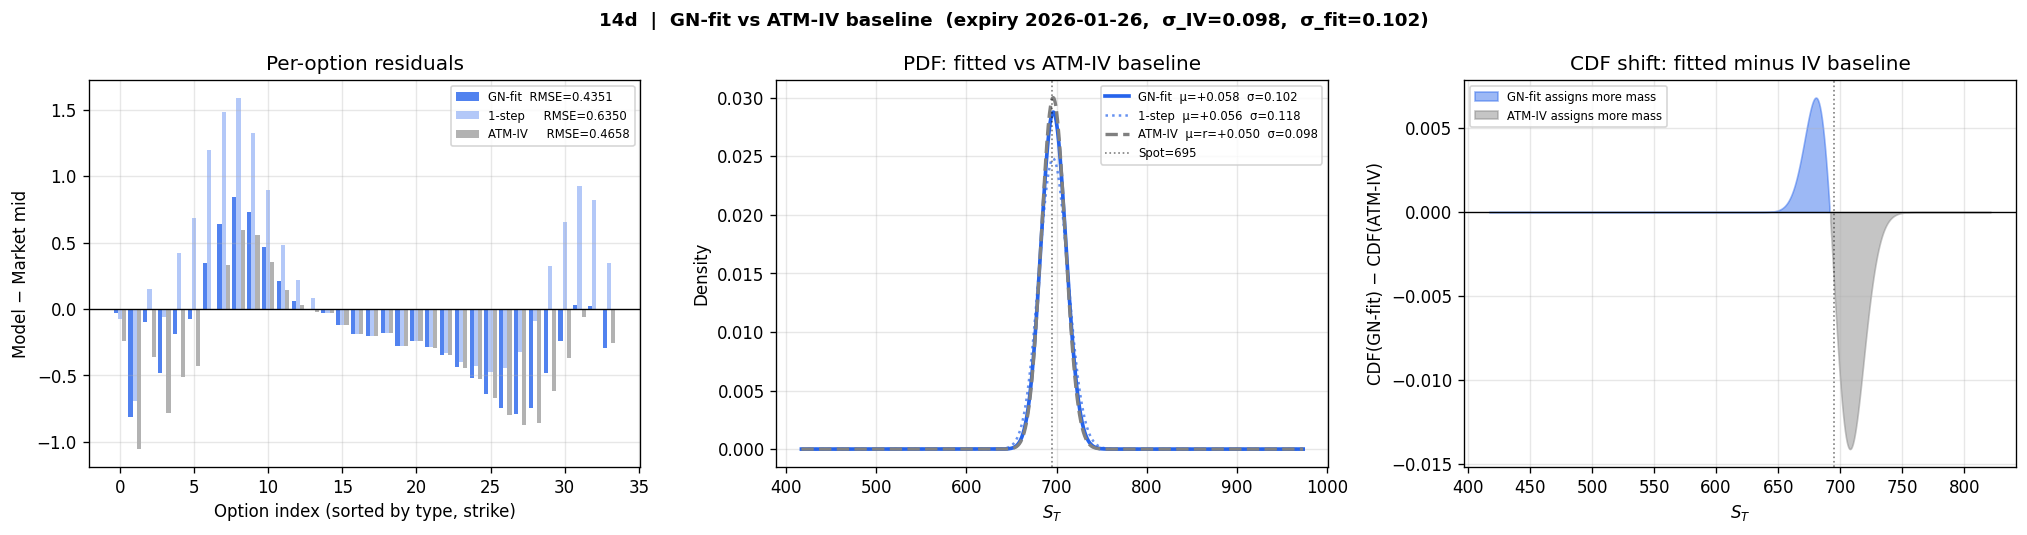

  [14d]  RMSE — GN-fit: 0.4351  |  1-step: 0.6350  |  ATM-IV: 0.4658  |  GN vs IV: +0.0307


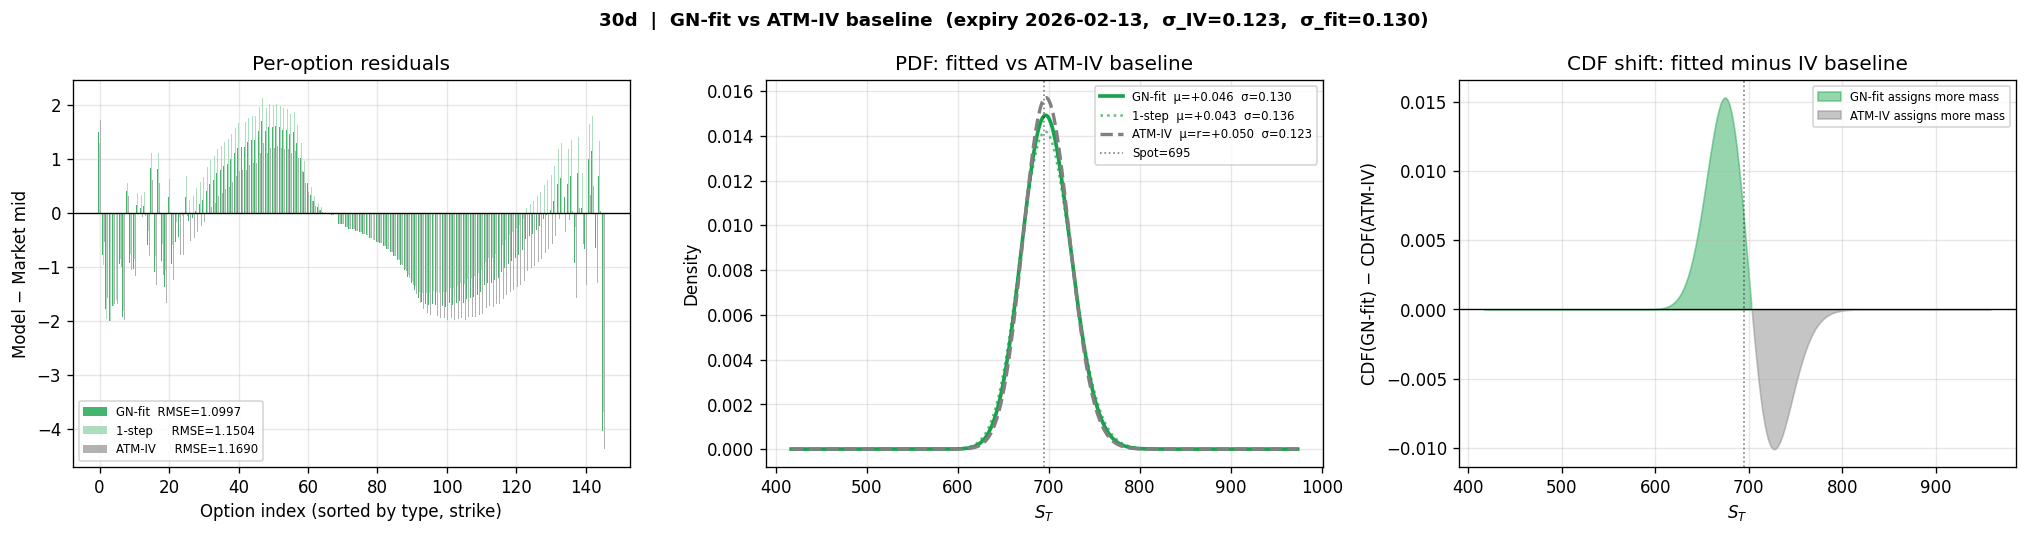

  [30d]  RMSE — GN-fit: 1.0997  |  1-step: 1.1504  |  ATM-IV: 1.1690  |  GN vs IV: +0.0693


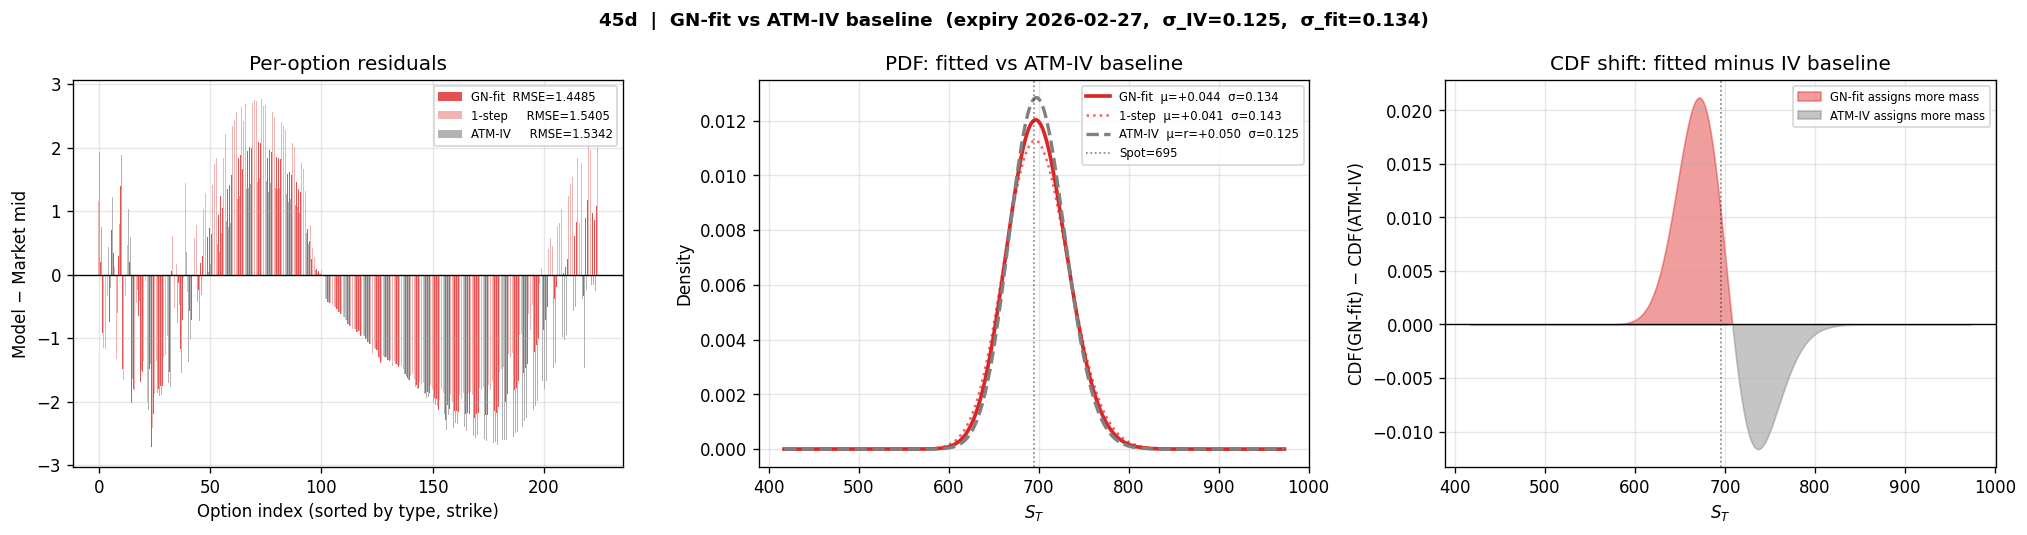

  [45d]  RMSE — GN-fit: 1.4485  |  1-step: 1.5405  |  ATM-IV: 1.5342  |  GN vs IV: +0.0857


In [12]:
_iv   = globals().get('iv_cache',  {})
_gn22 = globals().get('fits_gn',   {})

if not _iv:
    print("iv_cache is empty — re-run §3.2 overlay cell first.")
else:
    from scipy.stats import lognorm as lognorm_sp

    for label in ["14d", "30d", "45d"]:
        if label not in fits or label not in _iv:
            continue

        res_1s  = fits[label]
        iv_info = _iv[label]
        # Use GN option_df if available (has fit_price_gn); fall back to 1-step df
        gn_ran  = label in _gn22
        res_gn  = _gn22[label] if gn_ran else res_1s
        T_      = res_gn["T"]
        s0      = res_gn["spot"]
        color   = COLORS[label]

        # ── Build a clean working DataFrame ──────────────────────────────────
        # Always start from the single-step option_df so columns are consistent
        df_opts = res_1s["option_df"].copy()

        # GN model prices (recompute from GN params if GN ran, else 1-step)
        mu_gn    = res_gn["mu_fit"]
        sig_gn   = res_gn["sigma_fit"]
        df_opts["gn_price"] = lognormal_price_vec(df_opts, mu_gn, sig_gn, s0, T_)

        # 1-step model prices (already in option_df as "fit_price")
        df_opts["1s_price"] = lognormal_price_vec(
            df_opts, res_1s["mu_fit"], res_1s["sigma_fit"], s0, T_
        )

        # ATM-IV baseline prices
        df_opts["iv_price"] = np.array([
            lognormal_price(row["strike"], row["type"] == "call",
                            R_ANN, iv_info["sigma_iv"], s0, T_)
            for _, row in df_opts.iterrows()
        ])

        df_opts["gn_resid"] = df_opts["gn_price"] - df_opts["market_mid"]
        df_opts["1s_resid"] = df_opts["1s_price"] - df_opts["market_mid"]
        df_opts["iv_resid"] = df_opts["iv_price"]  - df_opts["market_mid"]

        rmse_gn = np.sqrt((df_opts["gn_resid"]**2).mean())
        rmse_1s = np.sqrt((df_opts["1s_resid"]**2).mean())
        rmse_iv = np.sqrt((df_opts["iv_resid"]**2).mean())

        gn_label = "GN-fit" if gn_ran else "1-step (GN not run)"

        fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
        fig.suptitle(
            f"{label}  |  {gn_label} vs ATM-IV baseline  "
            f"(expiry {iv_info['expiry']},  σ_IV={iv_info['sigma_iv']:.3f},  "
            f"σ_fit={sig_gn:.3f})",
            fontsize=11, fontweight="bold"
        )

        # ── Panel 1: per-option residuals ─────────────────────────────────────
        ax = axes[0]
        x = np.arange(len(df_opts))
        w = 0.28
        ax.bar(x - w,     df_opts["gn_resid"], w, color=color,    alpha=0.80,
               label=f"{gn_label}  RMSE={rmse_gn:.4f}")
        ax.bar(x,         df_opts["1s_resid"], w, color=color,    alpha=0.35,
               label=f"1-step     RMSE={rmse_1s:.4f}")
        ax.bar(x + w,     df_opts["iv_resid"], w, color="gray",   alpha=0.60,
               label=f"ATM-IV     RMSE={rmse_iv:.4f}")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xlabel("Option index (sorted by type, strike)")
        ax.set_ylabel("Model − Market mid")
        ax.set_title("Per-option residuals")
        ax.legend(fontsize=7)

        # ── Panel 2: PDF comparison ───────────────────────────────────────────
        ax = axes[1]
        S_grid = np.linspace(s0 * 0.60, s0 * 1.40, 800)

        sig_t_gn = max(sig_gn * np.sqrt(T_), 1e-6)
        m_gn     = np.log(s0) + (mu_gn - 0.5 * sig_gn**2) * T_
        pdf_gn   = lognorm.pdf(S_grid, s=sig_t_gn, scale=np.exp(m_gn))

        sig_t_1s = max(res_1s["sigma_fit"] * np.sqrt(T_), 1e-6)
        m_1s     = np.log(s0) + (res_1s["mu_fit"] - 0.5 * res_1s["sigma_fit"]**2) * T_
        pdf_1s   = lognorm.pdf(S_grid, s=sig_t_1s, scale=np.exp(m_1s))

        pdf_iv = iv_lognormal_pdf(S_grid, s0, iv_info["sigma_iv"], T_)

        ax.plot(S_grid, pdf_gn, lw=2.2, color=color,
                label=f"{gn_label}  μ={mu_gn:+.3f}  σ={sig_gn:.3f}")
        ax.plot(S_grid, pdf_1s, lw=1.5, color=color, ls=":", alpha=0.7,
                label=f"1-step  μ={res_1s['mu_fit']:+.3f}  σ={res_1s['sigma_fit']:.3f}")
        ax.plot(S_grid, pdf_iv, lw=2.0, color="gray", ls="--",
                label=f"ATM-IV  μ=r={R_ANN:+.3f}  σ={iv_info['sigma_iv']:.3f}")
        ax.axvline(s0, color="black", ls=":", lw=1.0, alpha=0.5, label=f"Spot={s0:.0f}")
        ax.set_xlabel("$S_T$")
        ax.set_ylabel("Density")
        ax.set_title("PDF: fitted vs ATM-IV baseline")
        ax.legend(fontsize=7)

        # ── Panel 3: CDF difference (GN-fit − IV baseline) ───────────────────
        ax = axes[2]
        cdf_gn = lognorm_sp.cdf(S_grid, s=sig_t_gn, scale=np.exp(m_gn))
        sig_iv_t = max(iv_info["sigma_iv"] * np.sqrt(T_), 1e-6)
        m_iv     = np.log(s0) + (R_ANN - 0.5 * iv_info["sigma_iv"]**2) * T_
        cdf_iv   = lognorm_sp.cdf(S_grid, s=sig_iv_t, scale=np.exp(m_iv))
        diff = cdf_gn - cdf_iv
        ax.fill_between(S_grid, diff, 0, where=(diff > 0), color=color, alpha=0.45,
                        label=f"{gn_label} assigns more mass")
        ax.fill_between(S_grid, diff, 0, where=(diff < 0), color="gray", alpha=0.45,
                        label="ATM-IV assigns more mass")
        ax.axhline(0, color="black", lw=0.8)
        ax.axvline(s0, color="black", ls=":", lw=1.0, alpha=0.5)
        ax.set_xlabel("$S_T$")
        ax.set_ylabel(f"CDF({gn_label}) − CDF(ATM-IV)")
        ax.set_title("CDF shift: fitted minus IV baseline")
        ax.legend(fontsize=7)

        plt.tight_layout()
        plt.show()

        print(f"  [{label}]  RMSE — {gn_label}: {rmse_gn:.4f}  |  "
              f"1-step: {rmse_1s:.4f}  |  ATM-IV: {rmse_iv:.4f}  "
              f"|  GN vs IV: {rmse_iv - rmse_gn:+.4f}")

---
## 4. Repeated-sample test: predicted μ and Σ vs realized

We test the chosen log-normal distribution (`TEST_DTE`) over many historical windows:

1. Draw `N_SAMPLES` chain dates from history (at least `MIN_DAYS_BACK` before the last close).  
2. On each date, fit the log-normal to calls + puts at `TEST_DTE`.  
3. Sample parameter uncertainty → sample $S_T$ → compute predicted μ and Σ for  
   **(underlying, ATM call, ATM put)**.  
4. Look up the **realized** outcome at expiry (or at the expiry date using SPY daily data).  
5. Aggregate: distribution of (predicted μ − realized return), predicted Σ vs realized Σ.

In [13]:
# ── Build pool of eligible test dates ──────────────────────────────────────
test_eligible = [
    d for d in chain_dates_all
    if (last_close_date - pd.Timestamp(d)).days >= MIN_DAYS_BACK
]

rng_test = np.random.default_rng(42)
if len(test_eligible) <= N_SAMPLES:
    sampled_dates = test_eligible
else:
    idx_sample = rng_test.choice(len(test_eligible), size=N_SAMPLES, replace=False)
    sampled_dates = [test_eligible[i] for i in sorted(idx_sample)]

print(f"TEST_DTE={TEST_DTE}  eligible={len(test_eligible)}  "
      f"sampling={len(sampled_dates)} dates")

TEST_DTE=30  eligible=485  sampling=60 dates


In [14]:
# ── Run test across sampled dates ──────────────────────────────────────────
ASSET_NAMES = ["underlying", "call", "put"]
test_rows = []   # one row per sampled date: predicted and realized mu
cov_pred_list = []  # predicted 3x3 Σ per date
cov_real_list = []  # realized 3x3 Σ per date

for chain_date in sampled_dates:
    try:
        ref_ts  = pd.Timestamp(chain_date)
        idx_ref = prices.index.get_indexer([ref_ts], method="ffill")[0]
        if idx_ref < 0:
            continue
        spot_ref = float(prices.iloc[idx_ref]["close"])

        opt_df, expiry_str, T_ref = load_options_for_dte(
            chain_date, TEST_DTE, spot_ref, r=R_ANN
        )
        recent_lr = prices.loc[prices.index <= ref_ts, "log_ret"].iloc[-LOOKBACK_DAYS:].dropna()
        mu_g  = float(recent_lr.mean() * 252) if len(recent_lr) else 0.0
        sig_g = max(float(recent_lr.std() * np.sqrt(252)) if len(recent_lr) >= 2 else 0.15, 1e-4)

        res = fit_lognormal(opt_df, spot_ref, T_ref, r=R_ANN,
                            mu_guess=mu_g, sigma_guess=sig_g)

        # ATM call and put (model price and market mid)
        calls_sub = opt_df[opt_df["type"] == "call"]
        puts_sub  = opt_df[opt_df["type"] == "put"]
        if len(calls_sub) == 0 or len(puts_sub) == 0:
            continue
        K_call = float(calls_sub.loc[(calls_sub["strike"] - spot_ref).abs().idxmin(), "strike"])
        K_put  = float(puts_sub.loc[(puts_sub["strike"]  - spot_ref).abs().idxmin(), "strike"])
        C0_model = lognormal_price(K_call, True,  res["mu_fit"], res["sigma_fit"], spot_ref, T_ref)
        P0_model = lognormal_price(K_put,  False, res["mu_fit"], res["sigma_fit"], spot_ref, T_ref)
        C0_mkt   = float(calls_sub[calls_sub["strike"] == K_call]["market_mid"].iloc[0])
        P0_mkt   = float(puts_sub [puts_sub ["strike"] == K_put ]["market_mid"].iloc[0])
        if C0_model < 1e-4 or P0_model < 1e-4 or C0_mkt < 1e-4 or P0_mkt < 1e-4:
            continue

        # ── Predicted distribution via parameter sampling ──
        evals, evecs = np.linalg.eigh(res["param_cov"])
        evals = np.clip(evals, 1e-10, None)
        sqrt_cov = evecs @ np.diag(np.sqrt(evals))
        theta_draws = np.array([res["mu_fit"], res["sigma_fit"]]) + \
            rng_test.standard_normal((N_PARAM_DRAWS, 2)) @ sqrt_cov.T
        mu_draws    = np.clip(theta_draws[:, 0], -2.0, 2.0)
        sigma_draws = np.clip(theta_draws[:, 1], 0.02, 1.0)

        pidx = rng_test.integers(0, N_PARAM_DRAWS, size=N_SCENARIOS)
        z    = rng_test.standard_normal(N_SCENARIOS)
        log_st = (np.log(spot_ref)
                  + (mu_draws[pidx] - 0.5 * sigma_draws[pidx]**2) * T_ref
                  + sigma_draws[pidx] * np.sqrt(T_ref) * z)
        S_T_s = np.exp(log_st)

        R_und_p  = (S_T_s - spot_ref) / spot_ref
        R_call_p = (np.maximum(S_T_s - K_call, 0.0) - C0_model) / C0_model
        R_put_p  = (np.maximum(K_put - S_T_s, 0.0) - P0_model) / P0_model
        R_pred   = np.column_stack([R_und_p, R_call_p, R_put_p])
        mu_pred_v  = R_pred.mean(axis=0)
        Sig_pred   = np.cov(R_pred, rowvar=False)

        # ── Realized outcome ──
        exp_ts  = pd.Timestamp(expiry_str)
        # realized end = expiry or last available, whichever is earlier
        real_end_ts = min(last_close_date, exp_ts)
        idx_end = prices.index.get_indexer([real_end_ts], method="ffill")[0]
        if idx_end < 0:
            continue
        spot_end    = float(prices.iloc[idx_end]["close"])
        R_und_real  = (spot_end - spot_ref) / spot_ref
        R_call_real = (max(spot_end - K_call, 0.0) - C0_mkt) / C0_mkt
        R_put_real  = (max(K_put - spot_end, 0.0)  - P0_mkt) / P0_mkt
        mu_real_v   = np.array([R_und_real, R_call_real, R_put_real])

        # ── Realized DAILY covariance (scaled to period) ──
        try:
            iv_obj = lambda sig: _bs_call_price(spot_ref, K_call, R_ANN, T_ref, sig) - C0_mkt
            iv_atm = float(brentq(iv_obj, 0.01, 2.0))
        except Exception:
            iv_atm = res["sigma_fit"]

        spy_slice  = prices.loc[ref_ts:real_end_ts, "close"]
        dates_sl   = spy_slice.index
        spots_sl   = spy_slice.values.astype(float)
        nd         = len(spots_sl)
        if nd < 3:
            continue

        T_rem = np.array([max((exp_ts - d).days / 365.0, 1e-6) for d in dates_sl])
        cv    = np.zeros(nd)
        pv    = np.zeros(nd)
        for i in range(nd):
            if dates_sl[i] < exp_ts and T_rem[i] > 1 / 365.0:
                cv[i] = max(_bs_call_price(spots_sl[i], K_call, R_ANN, T_rem[i], iv_atm), 0.01)
                pv[i] = max(_bs_put_price( spots_sl[i], K_put,  R_ANN, T_rem[i], iv_atm), 0.01)
            else:
                cv[i] = max(spots_sl[i] - K_call, 0.01)
                pv[i] = max(K_put - spots_sl[i],  0.01)

        r_und_d  = (spots_sl[1:] - spots_sl[:-1]) / spots_sl[:-1]
        r_call_d = (cv[1:] - cv[:-1]) / cv[:-1]
        r_put_d  = (pv[1:] - pv[:-1]) / pv[:-1]
        R_daily  = np.column_stack([r_und_d, r_call_d, r_put_d])
        n_days   = R_daily.shape[0]
        Sig_real = n_days * np.cov(R_daily, rowvar=False)

        test_rows.append(dict(
            chain_date=chain_date,
            expiry=expiry_str,
            actual_dte=round(T_ref * 365),
            spot_entry=spot_ref,
            spot_end=spot_end,
            mu_pred_und=mu_pred_v[0],  mu_real_und=mu_real_v[0],
            mu_pred_call=mu_pred_v[1], mu_real_call=mu_real_v[1],
            mu_pred_put=mu_pred_v[2],  mu_real_put=mu_real_v[2],
            vol_pred_und=float(np.sqrt(max(Sig_pred[0, 0], 0))),
            vol_pred_call=float(np.sqrt(max(Sig_pred[1, 1], 0))),
            vol_pred_put=float(np.sqrt(max(Sig_pred[2, 2], 0))),
            vol_real_und=float(np.sqrt(max(Sig_real[0, 0], 0))),
            vol_real_call=float(np.sqrt(max(Sig_real[1, 1], 0))),
            vol_real_put=float(np.sqrt(max(Sig_real[2, 2], 0))),
        ))
        cov_pred_list.append(Sig_pred)
        cov_real_list.append(Sig_real)

    except Exception:
        continue

test_df = pd.DataFrame(test_rows)
print(f"Test complete: {len(test_df)} windows with valid predictions and realized data.")
if len(test_df) > 0:
    print(test_df[["chain_date", "expiry", "actual_dte",
                   "mu_pred_und", "mu_real_und",
                   "mu_pred_call", "mu_real_call"]].head(10).to_string(index=False))

Test complete: 60 windows with valid predictions and realized data.
chain_date     expiry  actual_dte  mu_pred_und  mu_real_und  mu_pred_call  mu_real_call
2024-03-04 2024-04-05          32     0.004747     0.011966     -0.003844     -0.133423
2024-03-14 2024-04-12          29     0.001932    -0.007962      0.007899     -1.000000
2024-03-18 2024-04-19          32     0.007815    -0.034512      0.001039     -1.000000
2024-03-26 2024-04-26          31     0.008158    -0.020335      0.003469     -1.000000
2024-03-27 2024-04-26          30     0.003363    -0.028499      0.000488     -1.000000
2024-04-01 2024-05-03          32     0.006644    -0.020817      0.003772     -1.000000
2024-04-03 2024-05-03          30     0.006589    -0.015633      0.004680     -1.000000
2024-04-23 2024-05-24          31     0.003019     0.047048      0.006570      1.441667
2024-05-17 2024-06-14          28     0.006182     0.025177      0.006014      0.859649
2024-05-21 2024-06-21          31     0.007857     0

### 4.1 Predicted μ vs realized return — scatter and bias

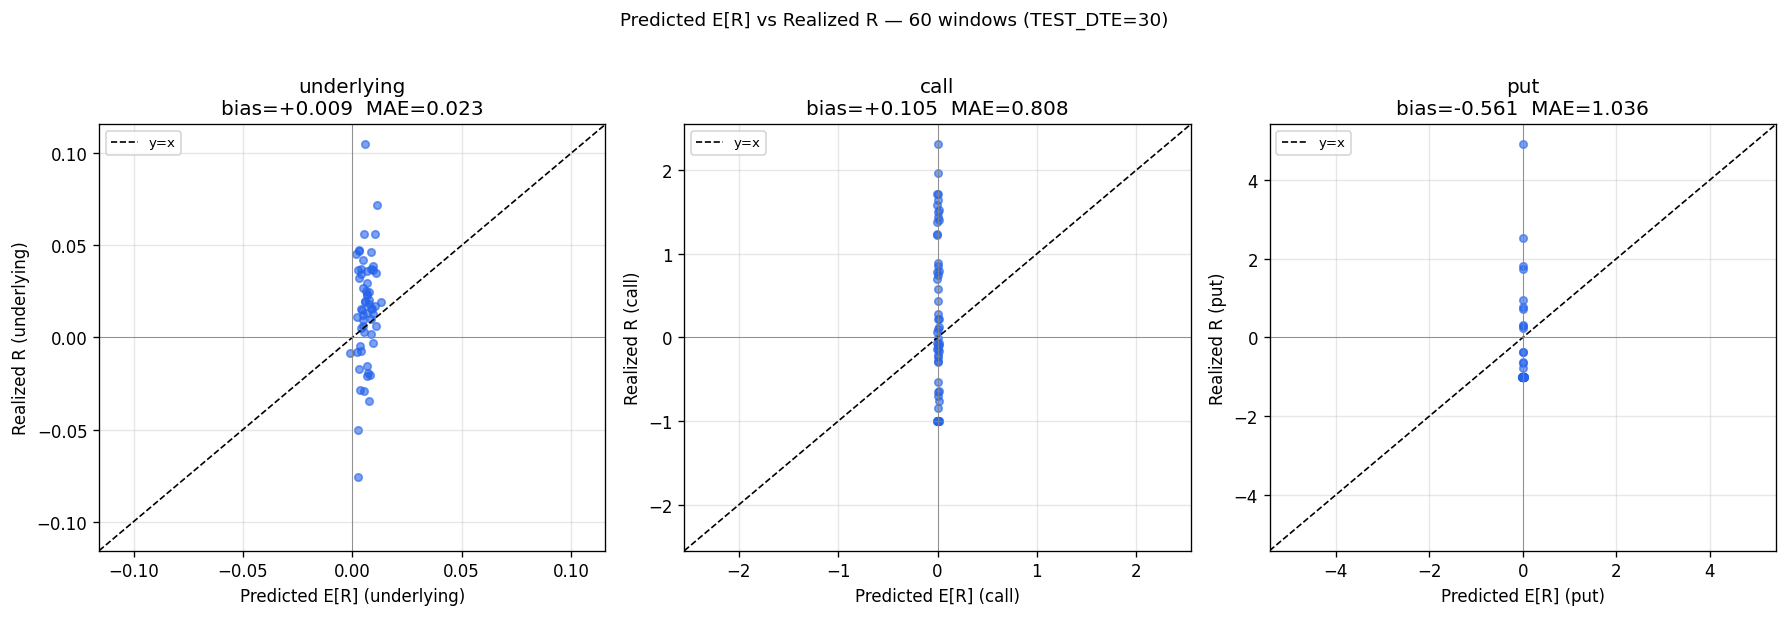

In [15]:
if len(test_df) == 0:
    print("No test results — skipping plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, asset, pred_col, real_col in zip(
        axes,
        ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        x = test_df[pred_col].values
        y = test_df[real_col].values
        ax.scatter(x, y, s=20, alpha=0.6, color="#2563eb")
        lim = max(abs(x).max(), abs(y).max()) * 1.1
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="y=x")
        ax.axhline(0, color="gray", lw=0.5)
        ax.axvline(0, color="gray", lw=0.5)
        bias = float((y - x).mean())
        mae  = float(np.abs(y - x).mean())
        ax.set_xlabel(f"Predicted E[R] ({asset})")
        ax.set_ylabel(f"Realized R ({asset})")
        ax.set_title(f"{asset}\nbias={bias:+.3f}  MAE={mae:.3f}")
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Predicted E[R] vs Realized R — {len(test_df)} windows "
        f"(TEST_DTE={TEST_DTE})",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

### 4.2 Predicted vol vs realized vol per asset

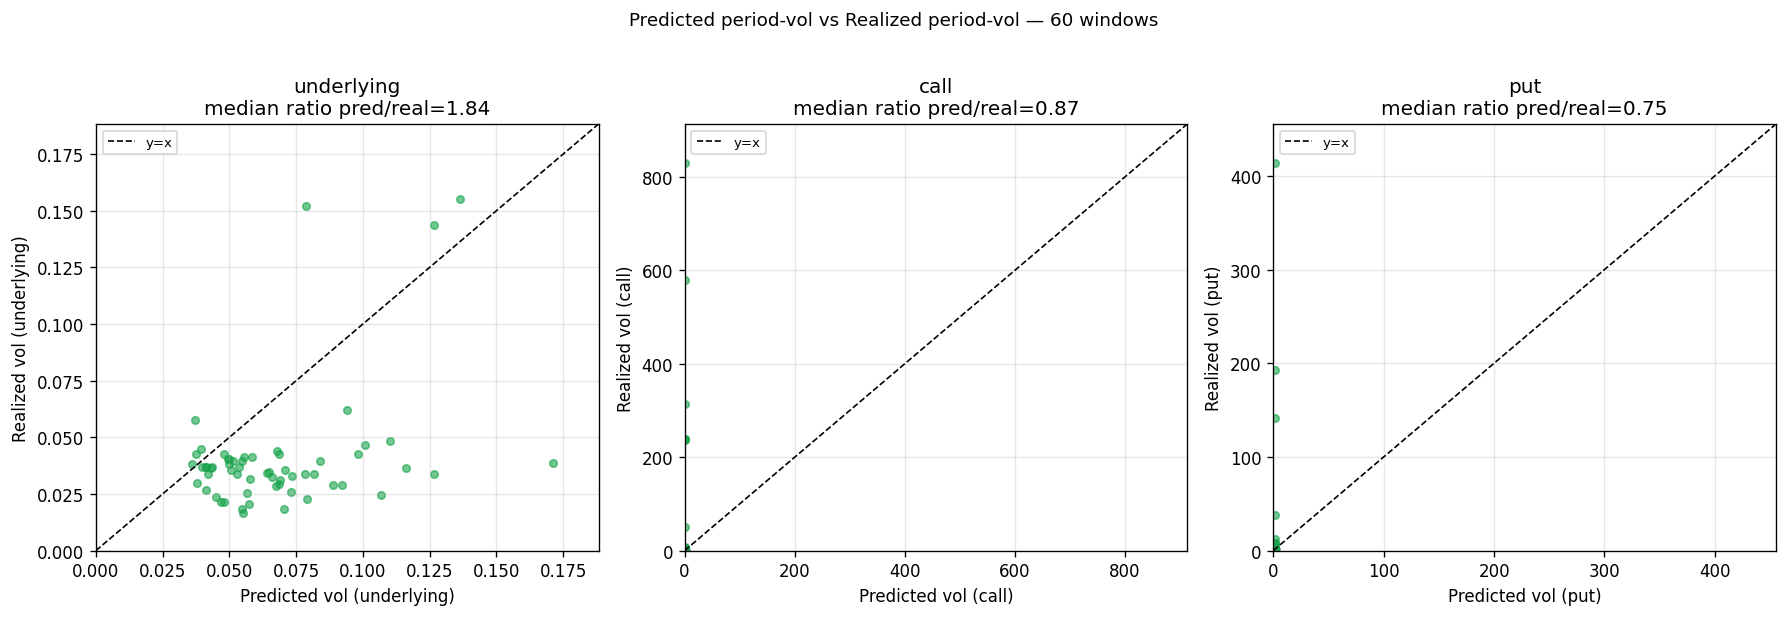

In [16]:
if len(test_df) == 0:
    print("No test results — skipping.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, asset, pred_col, real_col in zip(
        axes,
        ASSET_NAMES,
        ["vol_pred_und",  "vol_pred_call",  "vol_pred_put"],
        ["vol_real_und",  "vol_real_call",  "vol_real_put"],
    ):
        x = test_df[pred_col].values
        y = test_df[real_col].values
        ax.scatter(x, y, s=20, alpha=0.6, color="#16a34a")
        lim = max(x.max(), y.max()) * 1.1
        ax.plot([0, lim], [0, lim], "k--", lw=1, label="y=x")
        ratio = float(np.nanmean(x / np.where(y > 1e-9, y, np.nan)))
        ax.set_xlabel(f"Predicted vol ({asset})")
        ax.set_ylabel(f"Realized vol ({asset})")
        ax.set_title(f"{asset}\nmedian ratio pred/real={np.nanmedian(x/np.where(y>1e-9,y,np.nan)):.2f}")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Predicted period-vol vs Realized period-vol — {len(test_df)} windows",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

### 4.3 Average predicted and realized covariance matrices

Average PREDICTED covariance matrix (60 windows, TEST_DTE=30):
            underlying      call       put
underlying    0.005375  0.087194 -0.083475
call          0.087194  2.068435 -1.007919
put          -0.083475 -1.007919  2.288118

Average REALIZED covariance matrix:
            underlying          call          put
underlying    0.002350      1.404954    -0.372150
call          1.404954  21608.937282   -99.932291
put          -0.372150    -99.932291  3845.495926

Average PREDICTED correlation:
            underlying    call     put
underlying      1.0000  0.8269 -0.7527
call            0.8269  1.0000 -0.4633
put            -0.7527 -0.4633  1.0000

Average REALIZED correlation:
            underlying    call     put
underlying      1.0000  0.1972 -0.1238
call            0.1972  1.0000 -0.0110
put            -0.1238 -0.0110  1.0000


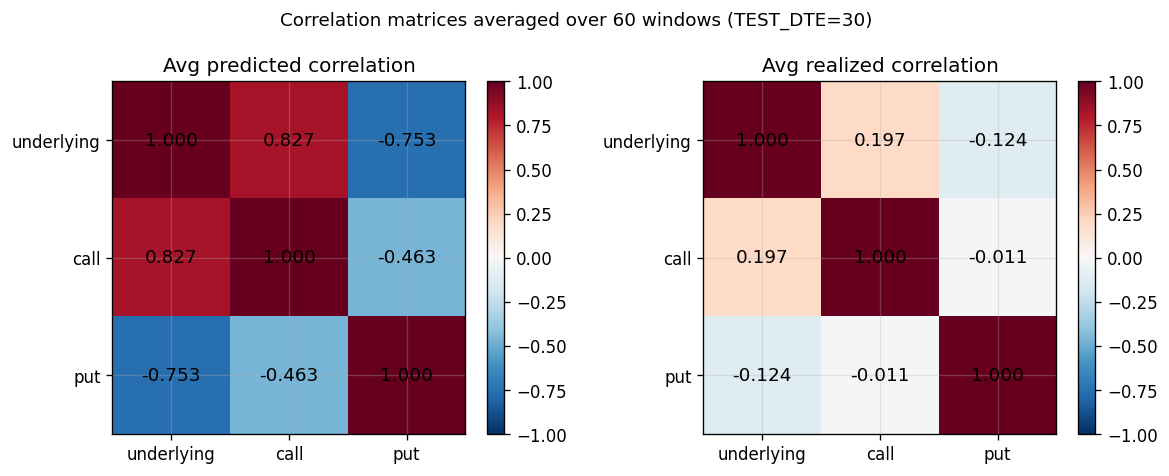

In [17]:
if len(cov_pred_list) == 0:
    print("No covariance data.")
else:
    Sig_pred_avg = np.mean(np.stack(cov_pred_list, axis=0), axis=0)
    Sig_real_avg = np.mean(np.stack(cov_real_list, axis=0), axis=0)

    def _to_corr(S):
        d = np.sqrt(np.maximum(np.diag(S), 1e-20))
        return S / np.outer(d, d)

    print(f"Average PREDICTED covariance matrix ({len(cov_pred_list)} windows, TEST_DTE={TEST_DTE}):")
    print(pd.DataFrame(Sig_pred_avg, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string())

    print(f"\nAverage REALIZED covariance matrix:")
    print(pd.DataFrame(Sig_real_avg, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string())

    print("\nAverage PREDICTED correlation:")
    print(pd.DataFrame(_to_corr(Sig_pred_avg), index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string())

    print("\nAverage REALIZED correlation:")
    print(pd.DataFrame(_to_corr(Sig_real_avg), index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string())

    # Heatmap comparison
    import matplotlib.colors as mcolors
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, mat, title in [
        (axes[0], _to_corr(Sig_pred_avg), "Avg predicted correlation"),
        (axes[1], _to_corr(Sig_real_avg), "Avg realized correlation"),
    ]:
        im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(ASSET_NAMES); ax.set_yticklabels(ASSET_NAMES)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center",
                        fontsize=11, color="black")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(
        f"Correlation matrices averaged over {len(cov_pred_list)} windows "
        f"(TEST_DTE={TEST_DTE})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

### 4.4 Realized-return percentile in predicted distribution

For each window and each asset, we record where the realized return falls in the predicted distribution. Under a well-calibrated model this should be roughly uniform on [0, 100].


── μ prediction summary (mean ± std of error = realized − predicted) ──
  underlying    bias=+0.0091  std=0.0291  MAE=0.0234  corr(pred,real)=0.227
  call          bias=+0.1046  std=0.9753  MAE=0.8080  corr(pred,real)=-0.143
  put           bias=-0.5608  std=1.0664  MAE=1.0356  corr(pred,real)=-0.011

── Volatility ratio (predicted / realized) ──
  underlying    median ratio=1.840  mean ratio=1.947  std=0.918
  call          median ratio=0.874  mean ratio=0.930  std=0.651
  put           median ratio=0.754  mean ratio=0.733  std=0.324


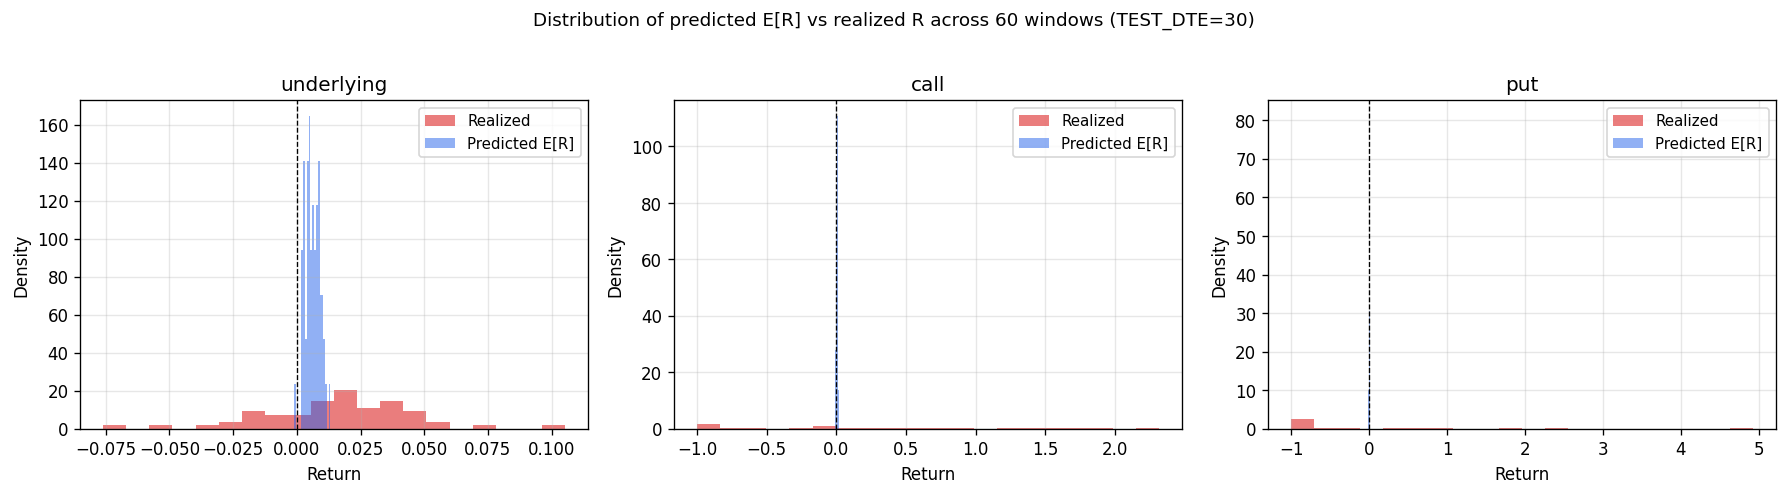

In [18]:
if len(test_df) == 0:
    print("No test results.")
else:
    # Summary statistics
    print("\n── μ prediction summary (mean ± std of error = realized − predicted) ──")
    for asset, pred_col, real_col in zip(
        ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        err = test_df[real_col] - test_df[pred_col]
        print(f"  {asset:12s}  bias={err.mean():+.4f}  std={err.std():.4f}  "
              f"MAE={err.abs().mean():.4f}  "
              f"corr(pred,real)={test_df[pred_col].corr(test_df[real_col]):.3f}")

    print("\n── Volatility ratio (predicted / realized) ──")
    for asset, pred_col, real_col in zip(
        ASSET_NAMES,
        ["vol_pred_und",  "vol_pred_call",  "vol_pred_put"],
        ["vol_real_und",  "vol_real_call",  "vol_real_put"],
    ):
        ratio = test_df[pred_col] / test_df[real_col].replace(0, np.nan)
        print(f"  {asset:12s}  median ratio={ratio.median():.3f}  "
              f"mean ratio={ratio.mean():.3f}  std={ratio.std():.3f}")

    # Distribution of predicted vs realized returns
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, asset, pred_col, real_col in zip(
        axes, ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        ax.hist(test_df[real_col], bins=20, alpha=0.6,
                color="#dc2626", label="Realized", density=True)
        ax.hist(test_df[pred_col], bins=20, alpha=0.5,
                color="#2563eb", label="Predicted E[R]", density=True)
        ax.axvline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{asset}")
        ax.set_xlabel("Return")
        ax.set_ylabel("Density")
        ax.legend(fontsize=9)

    plt.suptitle(
        f"Distribution of predicted E[R] vs realized R across "
        f"{len(test_df)} windows (TEST_DTE={TEST_DTE})",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

---
## 5. Walk-Forward Min-Variance Backtest — 2023 Full Year

**Data**: `optionsdx_csv` free-history research panel — SPY, AAPL, NVDA, TSLA  
**4 symbols × 250 daily dates × 5 assets each** (underlying + 2 calls + 2 puts, pre-cleaned, zero NaN).

**Three experiments — all pure minimum-variance (no μ used):**

| Experiment | Universe |
|---|---|
| **0 · Stocks only** | SPY, AAPL, NVDA, TSLA |
| **A · SPY options + stocks** | SPY_und, SPY_call1, SPY_put1, AAPL, NVDA, TSLA |
| **B · All options** | each symbol gets its own ATM call + ATM put |

**Covariance**: rolling 21-day empirical covariance of *realized* daily returns — the most direct use of the research panel data.  
**Rebalance**: every 5 trading days (weekly). Long-only, fully invested, weight cap 50%.  
**Benchmark**: equal-weight stocks (SPY + AAPL + NVDA + TSLA, 25% each, held static).

$$\Sigma_{\text{structural}} = \underbrace{V \,\sigma_{\text{und}}^2 T\, V^\top}_{\text{systematic, from GN }\sigma} + \underbrace{D}_{\text{empirical option noise floor}}$$

where $V = [1,\; \delta^{\%}_{\text{call}},\; \delta^{\%}_{\text{put}}]^\top$ and $\delta^{\%}_i = (\partial C_i/\partial S) \cdot S_0 / C_{i,0}$ converts price-delta to return-space sensitivity.  Robustness is added via $A_{\text{eff}} = \Sigma_{\text{structural}} + \varepsilon_{\text{wc}} \, V V^\top$.

**Two portfolios compared — both pure minimum-variance (no $\mu$ used):**
1. **Stocks only** — SPY underlying alone; baseline portfolio vol = $\sigma_{\text{GN}} \sqrt{T}$
2. **Stocks + Options** — $\{$SPY, ATM call, ATM put$\}$; three covariance variants:
   - Structural $\Sigma$ from GN fit + BS deltas
   - Robust $A_{\text{eff}}$ (adds $\varepsilon_{\text{wc}}$ penalty)
   - §4 average predicted $\Sigma$ (Monte-Carlo covariance from section 4, if available)

In [19]:
# ── Config ───────────────────────────────────────────────────────────────────
from pathlib import Path as _Path

_PANEL_PATH  = _Path("data/processed/free_history/research_panel_optionsdx_csv.parquet")
_LOOKBACK    = 21     # rolling-window trading days for empirical covariance
_REBAL_FREQ  = 5      # rebalance every N trading days
_MAX_WT      = 0.50   # maximum weight per single asset
_SYMS        = ["SPY", "AAPL", "NVDA", "TSLA"]

# ── Load research panel (2023, options + Greeks) ───────────────────────────────
_rp = pd.read_parquet(_PANEL_PATH)
_rp["date_t"] = pd.to_datetime(_rp["date_t"])
_rp = _rp.sort_values(["symbol", "date_t"]).reset_index(drop=True)

# ── Build wide returns DataFrame: date × all assets ──────────────────────────
_ret_blocks = []
for _sym in _SYMS:
    _sub = _rp[_rp["symbol"] == _sym].set_index("date_t")
    for _col, _new in [
        ("R_und_real",   f"{_sym}"),
        ("call_1_R_real", f"{_sym}_call1"),
        ("put_1_R_real",  f"{_sym}_put1"),
        ("call_2_R_real", f"{_sym}_call2"),
        ("put_2_R_real",  f"{_sym}_put2"),
    ]:
        if _col in _sub.columns:
            _ret_blocks.append(_sub[[_col]].rename(columns={_col: _new}))

_rets_all = pd.concat(_ret_blocks, axis=1).sort_index()

# ── Common date index (inner join — all 4 symbols present) ───────────────────
_common_dates = _rets_all.dropna(subset=_SYMS).index
_rets_all     = _rets_all.loc[_common_dates]

print(f"Returns matrix : {_rets_all.shape[0]} dates × {_rets_all.shape[1]} assets")
print(f"Date range     : {_rets_all.index.min().date()} → {_rets_all.index.max().date()}")
print(f"Assets         : {list(_rets_all.columns)}")
print(f"\nAnnualized stats (full sample):")
_ann = _rets_all.describe().T[["mean","std"]].copy()
_ann["ann_return"] = _ann["mean"]  * 252
_ann["ann_vol"]    = _ann["std"]   * np.sqrt(252)
print(_ann[["ann_return","ann_vol"]].map(lambda x: f"{x:.2%}").to_string())
print("\nNote: §5 walk-forward uses only this research panel window (high-quality options + Greeks).")
print("      No dependence on §3 `fits` — run this cell anytime after imports / helpers.")


Returns matrix : 245 dates × 20 assets
Date range     : 2023-01-05 → 2023-12-28
Assets         : ['SPY', 'SPY_call1', 'SPY_put1', 'SPY_call2', 'SPY_put2', 'AAPL', 'AAPL_call1', 'AAPL_put1', 'AAPL_call2', 'AAPL_put2', 'NVDA', 'NVDA_call1', 'NVDA_put1', 'NVDA_call2', 'NVDA_put2', 'TSLA', 'TSLA_call1', 'TSLA_put1', 'TSLA_call2', 'TSLA_put2']

Annualized stats (full sample):
           ann_return  ann_vol
SPY            23.00%   13.14%
SPY_call1     415.37%  567.79%
SPY_put1    -1479.15%  578.63%
SPY_call2     456.48%  597.90%
SPY_put2    -1555.25%  585.87%
AAPL           45.37%   19.98%
AAPL_call1    580.40%  508.29%
AAPL_put1   -1760.78%  599.73%
AAPL_call2    579.35%  689.37%
AAPL_put2   -2106.30%  630.65%
NVDA          137.23%   48.54%
NVDA_call1   1701.96%  898.85%
NVDA_put1   -2368.44%  629.57%
NVDA_call2   1817.52%  945.68%
NVDA_put2   -2495.00%  651.16%
TSLA          102.18%   52.59%
TSLA_call1    468.40%  582.41%
TSLA_put1   -1545.00%  625.38%
TSLA_call2    574.29%  636.51%
TSLA_p

In [20]:
import contextlib, io as _io

# ── Silence helper ─────────────────────────────────────────────────────────────
def _silent(fn, *args, **kwargs):
    with contextlib.redirect_stdout(_io.StringIO()):
        return fn(*args, **kwargs)


# ── Build mini option DataFrame from one research-panel row ──────────────────
def _mini_optdf(row):
    rows = []
    for slot, is_call in [("call_1",True),("call_2",True),("put_1",False),("put_2",False)]:
        K   = row.get(f"{slot}_strike")
        mid = row.get(f"{slot}_mid_t")
        if pd.notna(K) and pd.notna(mid) and float(mid) > 0.005:
            rows.append({"strike": float(K),
                         "type": "call" if is_call else "put",
                         "market_mid": float(mid)})
    return pd.DataFrame(rows) if len(rows) >= 2 else None


# ── GN fit + Delta-Gamma-Vega (DGV) daily covariance ────────────────────────
def _gn_cov_dgv(row, r=R_ANN, n_param=30, rng=None):
    # DGV decomposition (second-order Taylor of delta-C):
    #   Var(R_opt) ~ (Delta*S/C)^2 * sigma^2/252           <- delta systematic
    #              + (Gamma*S^2/2C)^2 * 2*sigma^4/252^2    <- gamma convexity
    #              + (Vega/C)^2 * sigma_IV_daily^2          <- vega vol-of-vol
    # This corrects terminal-payoff MC which underestimates daily option
    # variance because it ignores the ~39x delta leverage of ATM SPY options.
    if rng is None:
        rng = np.random.default_rng(42)

    opt_df = _mini_optdf(row)
    if opt_df is None:
        return None

    spot = float(row["spot_t"])
    T    = max(float(row.get("chosen_dte_t") or 21) / 365.0, 2/365)
    sig0 = max(float(row.get("call_1_iv_t")  or 0.20), 0.05)

    # Step 1: GN fit for forward-looking sigma
    try:
        res = _silent(fit_lognormal_gn, opt_df, spot_0=spot, T=T, r=r,
                      mu_guess=r, sigma_guess=sig0, max_iter=15)
    except Exception:
        try:
            res = fit_lognormal(opt_df, spot_0=spot, T=T, r=r,
                                mu_guess=r, sigma_guess=sig0)
        except Exception:
            return None

    # Sample sigma from Fisher distribution (uncertainty averaging)
    evals, evecs = np.linalg.eigh(res["param_cov"])
    evals    = np.clip(evals, 1e-12, None)
    sqrt_cov = evecs @ np.diag(np.sqrt(evals))
    draws    = (np.array([res["mu_fit"], res["sigma_fit"]])
                + rng.standard_normal((n_param, 2)) @ sqrt_cov.T)
    sigma    = float(np.clip(draws[:, 1], 0.02, 1.5).mean())
    var_und  = sigma**2 / 252   # daily underlying variance

    # Step 2: Greeks from research panel (preferred over BS approximation)
    delta_c = float(row.get("call_1_delta_t") or np.nan)
    gamma_c = float(row.get("call_1_gamma_t") or 0.0)
    vega_c  = float(row.get("call_1_vega_t")  or 0.0)
    C0_mkt  = float(row.get("call_1_mid_t")   or 0.0)
    delta_p = float(row.get("put_1_delta_t")  or np.nan)
    gamma_p = float(row.get("put_1_gamma_t")  or 0.0)
    vega_p  = float(row.get("put_1_vega_t")   or 0.0)
    P0_mkt  = float(row.get("put_1_mid_t")    or 0.0)

    # Fallback: BS greeks at GN sigma when panel greeks are missing
    if (np.isnan(delta_c) or np.isnan(delta_p)
            or C0_mkt < spot * 1e-4 or P0_mkt < spot * 1e-4):
        calls  = opt_df[opt_df["type"] == "call"]
        puts   = opt_df[opt_df["type"] == "put"]
        K_c_fb = float(calls.loc[(calls["strike"] - spot).abs().idxmin(), "strike"])
        K_p_fb = float(puts.loc[(puts["strike"]   - spot).abs().idxmin(), "strike"])
        sqrtT  = max(sigma * np.sqrt(T), 1e-6)
        d1_c   = (np.log(spot / K_c_fb) + (r + 0.5*sigma**2)*T) / sqrtT
        d1_p   = (np.log(spot / K_p_fb) + (r + 0.5*sigma**2)*T) / sqrtT
        delta_c = float(norm.cdf(d1_c))
        delta_p = float(norm.cdf(d1_p) - 1.0)
        phi     = float(norm.pdf(d1_c))
        gamma_c = gamma_p = phi / (spot * sigma * np.sqrt(T))
        vega_c  = vega_p  = spot * phi * np.sqrt(T)
        C0_mkt  = max(lognormal_price(K_c_fb, True,  res["mu_fit"], sigma, spot, T), spot * 1e-4)
        P0_mkt  = max(lognormal_price(K_p_fb, False, res["mu_fit"], sigma, spot, T), spot * 1e-4)

    # ATM strikes
    calls = opt_df[opt_df["type"] == "call"]
    puts  = opt_df[opt_df["type"] == "put"]
    K_c   = float(calls.loc[(calls["strike"] - spot).abs().idxmin(), "strike"])
    K_p   = float(puts.loc[(puts["strike"]   - spot).abs().idxmin(), "strike"])

    # Step 3: return-space leverages
    C_s    = max(C0_mkt, spot * 1e-4)
    P_s    = max(P0_mkt, spot * 1e-4)
    lev_c  = delta_c * spot / C_s            # Delta*S/C  (call: +15 to +100)
    lev_p  = delta_p * spot / P_s            # Delta*S/P  (put:  -15 to -100)
    glev_c = 0.5 * gamma_c * spot**2 / C_s   # Gamma*S^2 / (2*C)
    glev_p = 0.5 * gamma_p * spot**2 / P_s
    vret_c = vega_c / max(C0_mkt, 1e-4)     # Vega / C
    vret_p = vega_p / max(P0_mkt, 1e-4)

    # Step 4: DGV covariance (daily)
    levs        = np.array([1.0, lev_c, lev_p])
    Sigma_daily = np.outer(levs, levs) * var_und          # delta component
    Sigma_daily[1, 1] += glev_c**2 * 2.0 * var_und**2    # gamma component
    Sigma_daily[2, 2] += glev_p**2 * 2.0 * var_und**2
    IV_VOL_DAILY = 0.01                                    # ~1 vol-pt daily IV move
    Sigma_daily[1, 1] += (vret_c * IV_VOL_DAILY)**2       # vega component
    Sigma_daily[2, 2] += (vret_p * IV_VOL_DAILY)**2

    return dict(mu_fit=res["mu_fit"], sigma_fit=sigma,
                K_call=K_c, K_put=K_p, C0=C0_mkt, P0=P0_mkt, T=T, spot=spot,
                Sigma_daily=Sigma_daily, lev_c=lev_c, lev_p=lev_p)


# ── Assemble full N×N cross-asset covariance ──────────────────────────────────
def _build_full_cov(rebal_date, rp_idx, und_rets_df, syms, asset_cols,
                    lookback=_LOOKBACK):
    rng = np.random.default_rng(int(pd.Timestamp(rebal_date).value % (2**31)))

    gn = {}
    for sym in syms:
        df_sym = rp_idx.get(sym)
        if df_sym is None:
            continue
        avail = df_sym.loc[:rebal_date]
        if avail.empty:
            continue
        result = _gn_cov_dgv(avail.iloc[-1].to_dict(), rng=rng)
        if result:
            gn[sym] = result

    if not gn:
        raise ValueError(f"No DGV fits succeeded for {rebal_date}")

    # Rolling underlying cross-correlation
    end_loc   = und_rets_df.index.get_indexer([rebal_date], method="ffill")[0]
    start_loc = max(0, end_loc - lookback)
    corr_df   = und_rets_df.iloc[start_loc:end_loc][syms].dropna().corr()
    Corr      = corr_df.reindex(index=syms, columns=syms).fillna(0).values
    np.fill_diagonal(Corr, 1.0)

    TYPE_IDX  = {"": 0, "_call1": 1, "_put1": 2}
    sym_order = {s: i for i, s in enumerate(syms)}
    n         = len(asset_cols)
    sym_of    = [c.split("_")[0] for c in asset_cols]
    suf_of    = [c[len(c.split("_")[0]):] for c in asset_cols]

    Sigma = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            si, sj = sym_of[i], sym_of[j]
            ti = TYPE_IDX.get(suf_of[i], -1)
            tj = TYPE_IDX.get(suf_of[j], -1)
            if ti < 0 or tj < 0 or si not in gn or sj not in gn:
                continue
            gi, gj = gn[si], gn[sj]
            if si == sj:
                Sigma[i, j] = gi["Sigma_daily"][ti, tj]
            else:
                var_i  = max(gi["Sigma_daily"][0, 0], 1e-12)
                var_j  = max(gj["Sigma_daily"][0, 0], 1e-12)
                sens_i = 1.0 if ti == 0 else gi["Sigma_daily"][ti, 0] / var_i
                sens_j = 1.0 if tj == 0 else gj["Sigma_daily"][tj, 0] / var_j
                rho    = Corr[sym_order[si], sym_order[sj]]
                Sigma[i, j] = sens_i * rho * sens_j * np.sqrt(var_i * var_j)

    Sigma = 0.5 * (Sigma + Sigma.T) + 1e-7 * np.eye(n)
    return Sigma, gn


# ── Walk-forward engine: DGV covariance + individual option cap ───────────────
def _wf_gn(rets_df, asset_cols, syms, rp_idx, label,
            lookback=_LOOKBACK, rebal_freq=_REBAL_FREQ,
            max_wt=_MAX_WT, max_opt_wt=0.05,
            min_ann_return=None):
    cols        = [c for c in asset_cols if c in rets_df.columns]
    rets        = rets_df[cols].copy()
    dates       = rets.index
    und_rets_df = rets_df[syms].copy()

    port_val = {}
    wts_hist = {}
    cur_wts  = {c: 1.0 / len(cols) for c in cols}
    port_val[dates[lookback - 1]] = 1.0

    for i in range(lookback, len(dates)):
        date = dates[i]

        if (i - lookback) % rebal_freq == 0:
            try:
                Sigma, _ = _build_full_cov(date, rp_idx, und_rets_df,
                                           syms, cols, lookback)
                n  = len(cols)
                w  = cp.Variable(n, nonneg=True)
                constraints = [cp.sum(w) == 1, w <= max_wt]

                # Individual option cap
                for k, c in enumerate(cols):
                    if "_call" in c or "_put" in c:
                        constraints.append(w[k] <= max_opt_wt)

                if min_ann_return is not None:
                    mu_daily = np.zeros(n)
                    for k, c in enumerate(cols):
                        if c in syms:
                            hist = rets.iloc[i - lookback:i][c].dropna()
                            mu_daily[k] = float(hist.mean()) if len(hist) else 0.0
                    constraints.append(mu_daily @ w >= min_ann_return / 252)

                prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), constraints)
                prob.solve(solver=cp.CLARABEL, warm_start=True)
                if w.value is None:
                    prob.solve(solver=cp.SCS)

                if w.value is not None:
                    wv = np.clip(np.asarray(w.value).flatten(), 0, 1)
                    wv /= wv.sum()
                    cur_wts = dict(zip(cols, wv))
            except Exception:
                pass

            wts_hist[date] = cur_wts.copy()

        r_port = sum(
            cur_wts.get(c, 0.0) * float(rets.loc[date, c])
            for c in cur_wts
            if c in rets.columns and pd.notna(rets.loc[date, c])
        )
        prev = list(port_val.keys())[-1]
        port_val[date] = port_val[prev] * (1.0 + r_port)

    return pd.Series(port_val, name=label), pd.DataFrame(wts_hist).T.fillna(0.0)


# ── Empirical walk-forward for stocks only ─────────────────────────────────────
def _wf_minvar(rets_df, asset_cols, label,
               lookback=_LOOKBACK, rebal_freq=_REBAL_FREQ, max_wt=_MAX_WT):
    cols   = [c for c in asset_cols if c in rets_df.columns]
    rets   = rets_df[cols].copy()
    dates  = rets.index

    port_val = {}
    wts_hist = {}
    cur_wts  = {c: 1.0 / len(cols) for c in cols}
    port_val[dates[lookback - 1]] = 1.0

    for i in range(lookback, len(dates)):
        date = dates[i]

        if (i - lookback) % rebal_freq == 0:
            window = rets.iloc[i - lookback: i]
            valid  = [c for c in cols if window[c].notna().sum() >= lookback // 2]
            if len(valid) >= 2:
                Sig = np.cov(window[valid].dropna().T)
                Sig = 0.5 * (Sig + Sig.T) + 1e-7 * np.eye(len(valid))
                w   = cp.Variable(len(valid), nonneg=True)
                prob = cp.Problem(
                    cp.Minimize(cp.quad_form(w, Sig)),
                    [cp.sum(w) == 1, w <= max_wt]
                )
                prob.solve(solver=cp.CLARABEL, warm_start=True)
                if w.value is None:
                    prob.solve(solver=cp.SCS)
                if w.value is not None:
                    wv = np.clip(np.asarray(w.value).flatten(), 0, 1)
                    wv /= wv.sum()
                    cur_wts = dict(zip(valid, wv))
            wts_hist[date] = cur_wts.copy()

        r_port = sum(
            cur_wts.get(c, 0.0) * float(rets.loc[date, c])
            for c in cur_wts
            if c in rets.columns and pd.notna(rets.loc[date, c])
        )
        prev = list(port_val.keys())[-1]
        port_val[date] = port_val[prev] * (1.0 + r_port)

    return pd.Series(port_val, name=label), pd.DataFrame(wts_hist).T.fillna(0.0)


def _port_stats(path, label, rf_daily=R_ANN / 252):
    daily_r  = path.pct_change().dropna()
    ann_ret  = float((path.iloc[-1] / path.iloc[0]) ** (252 / len(daily_r)) - 1)
    ann_vol  = float(daily_r.std() * np.sqrt(252))
    sharpe   = (ann_ret - R_ANN) / ann_vol if ann_vol > 0 else np.nan
    cum_max  = path.cummax()
    drawdown = (path / cum_max - 1).min()
    return {"label": label, "ann_return": ann_ret, "ann_vol": ann_vol,
            "sharpe": sharpe, "max_dd": drawdown, "total_return": path.iloc[-1] - 1}


print("Walk-forward engine ready  (DGV covariance · 5% individual option cap).")


Walk-forward engine ready  (DGV covariance · 5% individual option cap).


Running Exp 0: Stocks only (empirical Σ, 2023) ...
  Final value: 1.2082

Running Exp A: SPY opts + stocks  [DGV Σ, 5% cap, no floor] ...
  Final value: 1.0501

Running Exp A+: SPY opts + stocks  [DGV Σ, 5% cap, 5% floor, μ_opts=0] ...
  Final value: 1.0458

Running Exp B: All opts  [DGV Σ, 5% cap] ...
  Final value: 0.9900


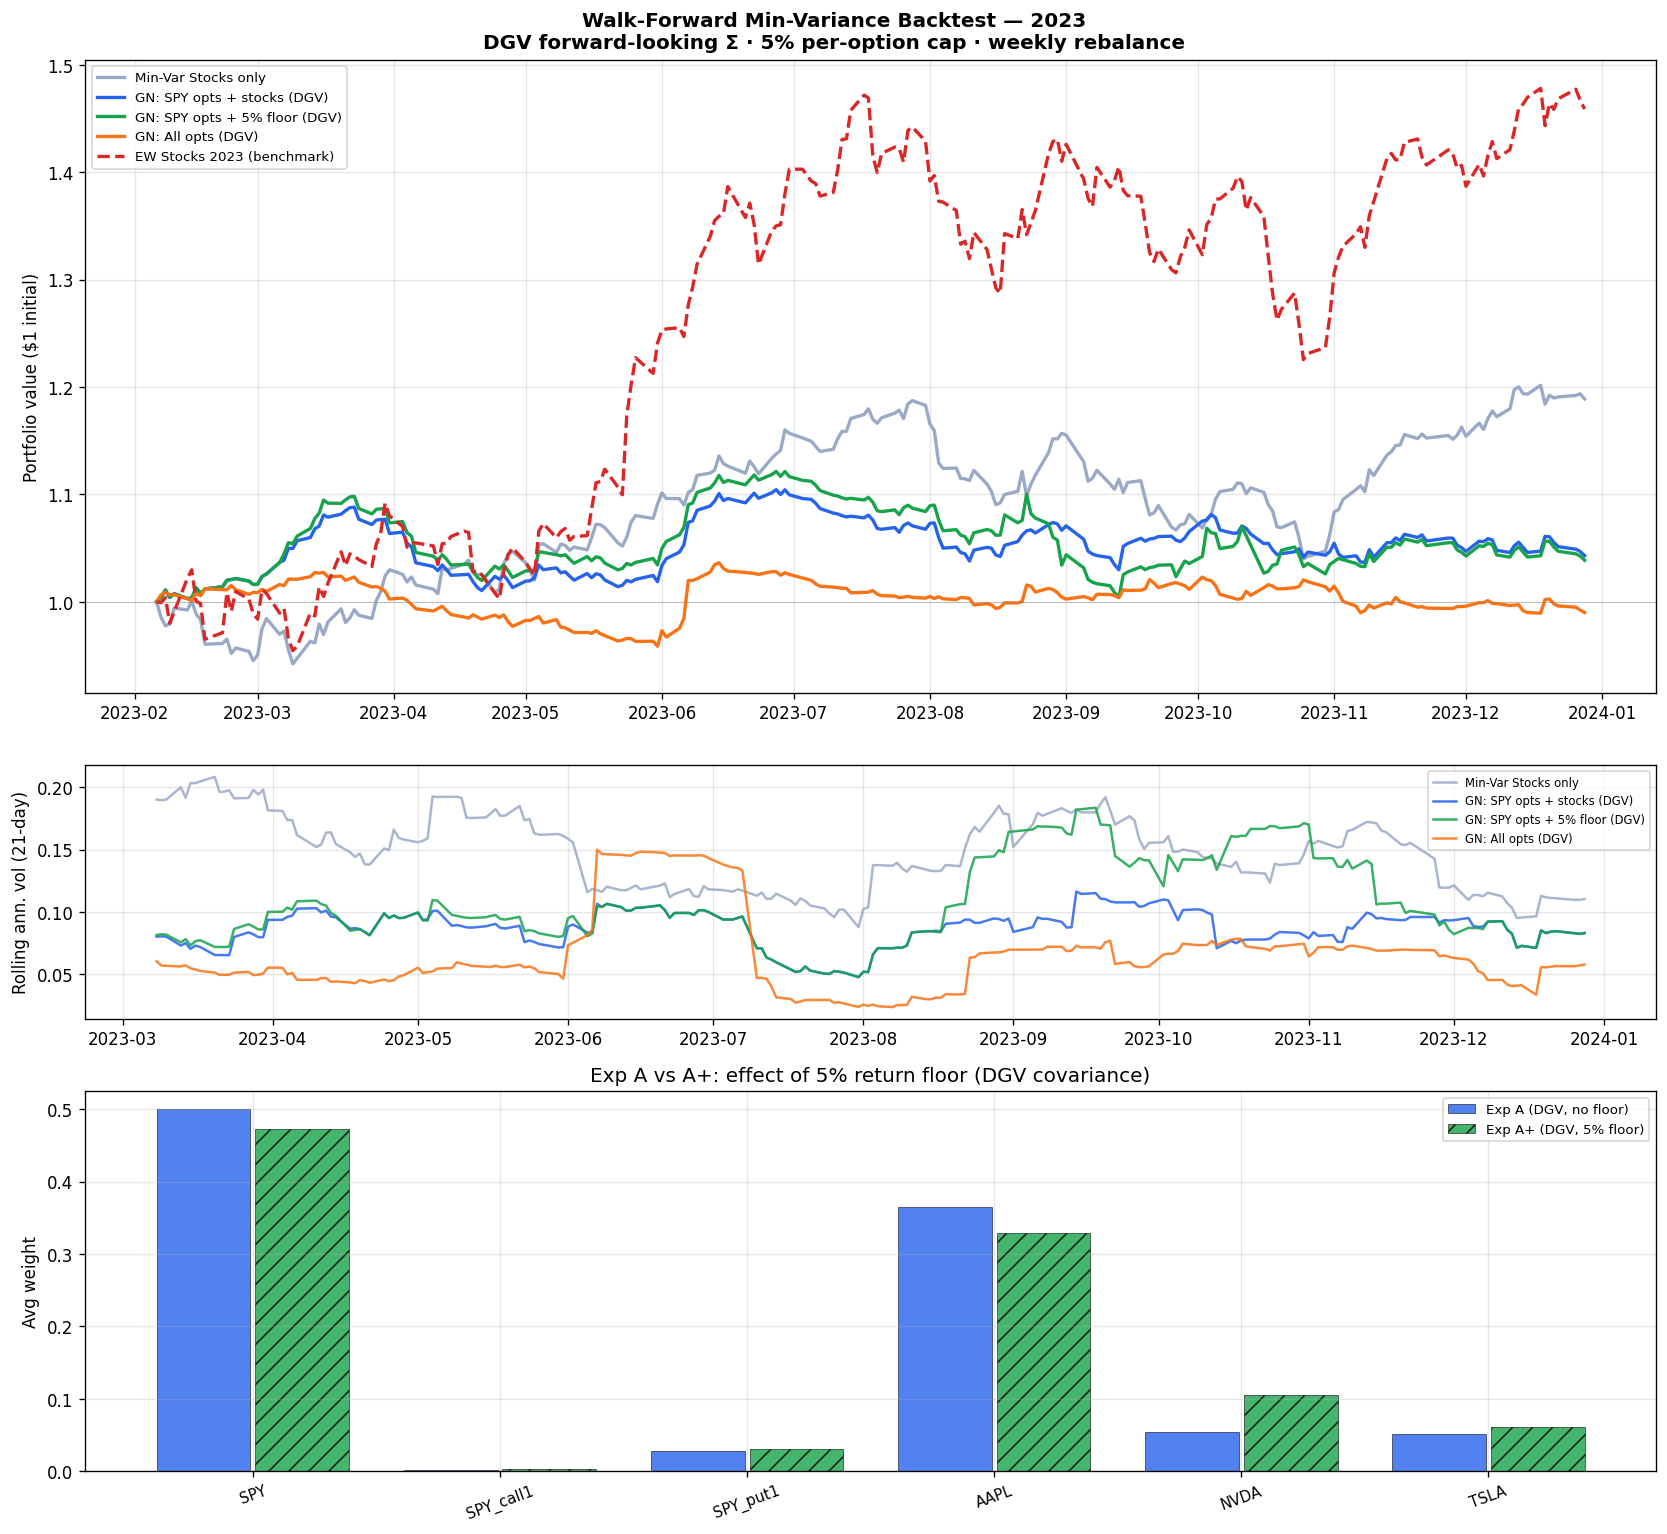


─── 2023 Performance Summary (DGV covariance) ───────────────────────
                              Total Ret Ann Ret Ann Vol   Sharpe   Max DD
label                                                                    
Min-Var Stocks only              18.89%  21.59%  15.02%  110.42%  -12.41%
GN: SPY opts + stocks (DGV)       4.30%   4.87%   8.89%   -1.46%   -7.14%
GN: SPY opts + 5% floor (DGV)     3.87%   4.38%  10.99%   -5.60%  -10.48%
GN: All opts (DGV)               -1.01%  -1.14%   7.12%  -86.23%   -6.70%
EW Stocks 2023 (benchmark)       45.88%  53.22%  25.06%  192.43%  -16.74%

─── Average weights ─────────────────────────────────────────────────
  Exp 0: SPY=0.500  AAPL=0.480  NVDA=0.016
  Exp A (DGV): SPY=0.500  AAPL=0.365  NVDA=0.054  TSLA=0.051  SPY_put1=0.028
  Exp A+ (DGV): SPY=0.473  AAPL=0.329  NVDA=0.105  TSLA=0.061  SPY_put1=0.030
  Exp B (DGV): SPY=0.458  AAPL=0.287  NVDA=0.118  TSLA=0.093  AAPL_put1=0.012  SPY_put1=0.011  NVDA_put1=0.010  TSLA_put1=0.010


In [21]:
# ── Asset universes ───────────────────────────────────────────────────────────
_UNIV_STOCKS = _SYMS
_UNIV_A      = ["SPY", "SPY_call1", "SPY_put1", "AAPL", "NVDA", "TSLA"]
_UNIV_B      = [f"{s}{sfx}" for s in _SYMS for sfx in ["", "_call1", "_put1"]]

# ── Pre-index research panel ──────────────────────────────────────────────────
_rp_idx = {sym: _rp[_rp["symbol"] == sym].set_index("date_t").sort_index()
           for sym in _SYMS}

# Equal-weight benchmark (2023 panel dates)
_ew_daily = _rets_all[_SYMS].mean(axis=1)
_ew_path  = (1 + _ew_daily.iloc[_LOOKBACK:]).cumprod()
_ew_path  = _ew_path / _ew_path.iloc[0]
_ew_path.name = "EW Stocks 2023 (benchmark)"

# Exp 0: Stocks only — empirical Σ
print("Running Exp 0: Stocks only (empirical Σ, 2023) ...")
_path0, _wts0 = _wf_minvar(_rets_all, _UNIV_STOCKS, "Min-Var Stocks only")
print(f"  Final value: {_path0.iloc[-1]:.4f}")

# Exp A: SPY options + stocks — DGV Σ, 5% option cap
print("\nRunning Exp A: SPY opts + stocks  [DGV Σ, 5% cap, no floor] ...")
_pathA, _wtsA = _wf_gn(
    _rets_all, _UNIV_A, _SYMS, _rp_idx,
    "GN: SPY opts + stocks (DGV)"
)
print(f"  Final value: {_pathA.iloc[-1]:.4f}")

# Exp A+: same + 5% return floor; μ_options ≡ 0
print("\nRunning Exp A+: SPY opts + stocks  [DGV Σ, 5% cap, 5% floor, μ_opts=0] ...")
_pathAp, _wtsAp = _wf_gn(
    _rets_all, _UNIV_A, _SYMS, _rp_idx,
    "GN: SPY opts + 5% floor (DGV)",
    min_ann_return=0.05,
)
print(f"  Final value: {_pathAp.iloc[-1]:.4f}")

# Exp B: all symbols with options — DGV Σ, 5% option cap
print("\nRunning Exp B: All opts  [DGV Σ, 5% cap] ...")
_pathB, _wtsB = _wf_gn(
    _rets_all, _UNIV_B, _SYMS, _rp_idx,
    "GN: All opts (DGV)"
)
print(f"  Final value: {_pathB.iloc[-1]:.4f}")

# ── Align paths ───────────────────────────────────────────────────────────────
_all_raw  = [_path0, _pathA, _pathAp, _pathB, _ew_path]
_start_dt = max(p.index.min() for p in _all_raw)
_paths    = [p.loc[_start_dt:] / float(p.loc[_start_dt]) for p in _all_raw]

PORT_COLORS5 = ["#9aa9c6", "#2563eb", "#16a34a", "#f97316", "#dc2626"]

# ── Figure: 2023 walk-forward ─────────────────────────────────────────────────
fig2, axes2 = plt.subplots(3, 1, figsize=(14, 13),
                            gridspec_kw={"height_ratios": [2.5, 1, 1.5]})
fig2.suptitle("Walk-Forward Min-Variance Backtest — 2023\n"
              "DGV forward-looking Σ · 5% per-option cap · weekly rebalance",
              fontsize=12, fontweight="bold")

ax = axes2[0]
for path, col in zip(_paths, PORT_COLORS5):
    ls = "--" if "benchmark" in path.name.lower() else "-"
    ax.plot(path.index, path.values, lw=2.0, color=col, ls=ls, label=path.name)
ax.axhline(1.0, color="gray", lw=0.6, alpha=0.4)
ax.set_ylabel("Portfolio value ($1 initial)")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

ax = axes2[1]
for path, col in zip(_paths[:4], PORT_COLORS5):
    r = path.pct_change().dropna()
    ax.plot(r.rolling(21).std().mul(252**0.5).index,
            r.rolling(21).std().mul(252**0.5).values,
            lw=1.5, color=col, alpha=0.85, label=path.name)
ax.set_ylabel("Rolling ann. vol (21-day)")
ax.legend(fontsize=7)

ax = axes2[2]
for wts_df, lbl, col, hatch in [(_wtsA,  "Exp A (DGV, no floor)",  "#2563eb", ""),
                                  (_wtsAp, "Exp A+ (DGV, 5% floor)", "#16a34a", "//")]:
    if wts_df.empty:
        continue
    mean_w = wts_df.mean().reindex(_UNIV_A).fillna(0)
    x_pos  = np.arange(len(_UNIV_A))
    offset = -0.2 if hatch == "" else 0.2
    ax.bar(x_pos + offset, mean_w.values, 0.38, color=col, alpha=0.8,
           hatch=hatch, edgecolor="k", lw=0.4, label=lbl)
ax.set_xticks(np.arange(len(_UNIV_A)))
ax.set_xticklabels(_UNIV_A, rotation=20, fontsize=9)
ax.set_ylabel("Avg weight")
ax.set_title("Exp A vs A+: effect of 5% return floor (DGV covariance)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Performance summary ───────────────────────────────────────────────────────
_stats_rows = [_port_stats(p, p.name) for p in _paths]
_stats_df   = pd.DataFrame(_stats_rows).set_index("label")

print("\n─── 2023 Performance Summary (DGV covariance) ───────────────────────")
print(_stats_df[["total_return","ann_return","ann_vol","sharpe","max_dd"]]
      .rename(columns={"total_return":"Total Ret","ann_return":"Ann Ret",
                       "ann_vol":"Ann Vol","sharpe":"Sharpe","max_dd":"Max DD"})
      .map(lambda x: f"{x:.2%}" if abs(x)<=5 else f"{x:.3f}").to_string())

print("\n─── Average weights ─────────────────────────────────────────────────")
for wts_df, lbl in [(_wts0,"Exp 0"),(_wtsA,"Exp A (DGV)"),
                     (_wtsAp,"Exp A+ (DGV)"),(_wtsB,"Exp B (DGV)")]:
    if wts_df.empty:
        continue
    mw  = wts_df.mean().sort_values(ascending=False)
    mw  = mw[mw > 0.005]
    row = "  ".join(f"{c}={v:.3f}" for c, v in mw.items())
    print(f"  {lbl}: {row}")


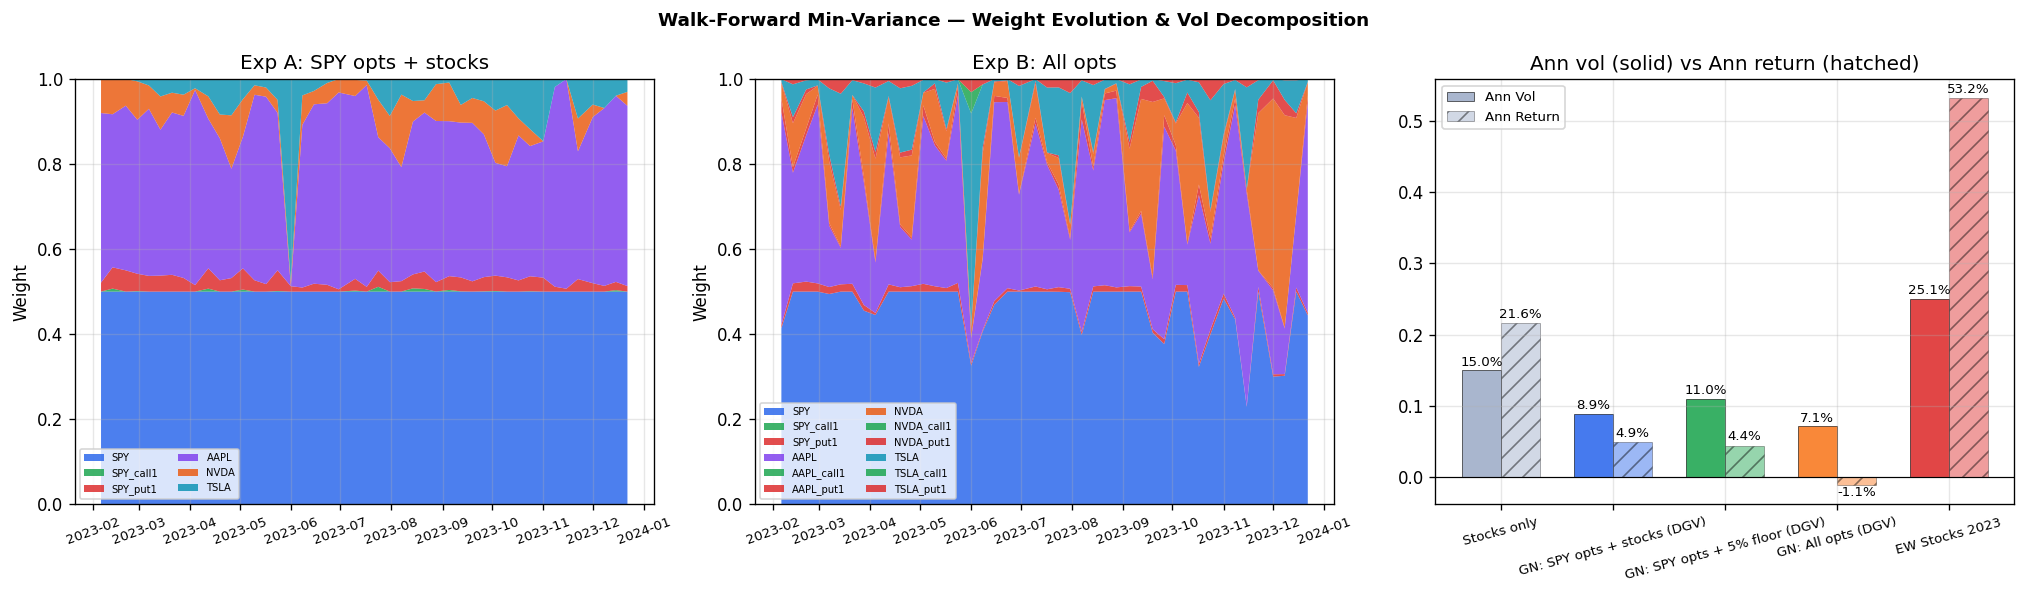


─── Realized daily-return covariance (diagonal = variance) ─────────────
                              Min-Var Stocks only GN: SPY opts + stocks (DGV) GN: SPY opts + 5% floor (DGV)
Min-Var Stocks only                        0.0226                      0.0032                        0.0027
GN: SPY opts + stocks (DGV)                0.0032                      0.0079                        0.0079
GN: SPY opts + 5% floor (DGV)              0.0027                      0.0079                        0.0121


/var/folders/v7/fy28j8pd6yb_vb5vddcfccd00000gn/T/ipykernel_24391/1124864430.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(_realized_cov.applymap(lambda x: f"{x:.4f}").to_string())


In [22]:
# ── Detailed view: weight over time + per-experiment vol reduction ────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Walk-Forward Min-Variance — Weight Evolution & Vol Decomposition",
             fontsize=11, fontweight="bold")

# Panel 1 & 2: weight stacks for Exp A and Exp B
for ax, wts_df, lbl, univ in [
    (axes[0], _wtsA, "Exp A: SPY opts + stocks", _UNIV_A),
    (axes[1], _wtsB, "Exp B: All opts",           _UNIV_B),
]:
    if wts_df.empty:
        ax.text(0.5, 0.5, "No weights", ha="center", va="center", transform=ax.transAxes)
        continue
    # align columns, fill missing with 0
    plot_cols = [c for c in univ if c in wts_df.columns]
    wts_plot  = wts_df[plot_cols].fillna(0.0)
    # color: blue=underlying, green=call, red=put
    c_map = {"call": "#16a34a", "put": "#dc2626"}
    colors_s = []
    base_colors = ["#2563eb","#7c3aed","#ea580c","#0891b2"]
    sym_idx = {s: i for i, s in enumerate(_SYMS)}
    for col in plot_cols:
        if "_call" in col:   colors_s.append(c_map["call"])
        elif "_put" in col:  colors_s.append(c_map["put"])
        else:
            i = sym_idx.get(col, 0)
            colors_s.append(base_colors[i % len(base_colors)])

    ax.stackplot(wts_plot.index, *[wts_plot[c] for c in plot_cols],
                 labels=plot_cols, colors=colors_s, alpha=0.82)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Weight")
    ax.set_title(lbl)
    ax.legend(fontsize=6, loc="lower left", ncol=2)
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)

# Panel 3: annualized vol and return bar comparison
ax = axes[2]
_labels_bar = [r["label"].replace("Min-Var ","").replace(" (benchmark)","")
               for r in _stats_rows]
_vols_bar   = [r["ann_vol"]    for r in _stats_rows]
_rets_bar   = [r["ann_return"] for r in _stats_rows]

x_b = np.arange(len(_labels_bar))
w_b = 0.35
bars_v = ax.bar(x_b - w_b/2, _vols_bar, w_b, color=PORT_COLORS5, alpha=0.85,
                label="Ann Vol", edgecolor="k", lw=0.4)
bars_r = ax.bar(x_b + w_b/2, _rets_bar, w_b, color=PORT_COLORS5, alpha=0.45,
                label="Ann Return", edgecolor="k", lw=0.4, hatch="//")
for bar, v in zip(bars_v, _vols_bar):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f"{v:.1%}", ha="center", va="bottom", fontsize=8)
for bar, v in zip(bars_r, _rets_bar):
    ypos = v + 0.003 if v >= 0 else v - 0.02
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f"{v:.1%}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.7)
ax.set_xticks(x_b)
ax.set_xticklabels(_labels_bar, rotation=15, fontsize=8)
ax.set_title("Ann vol (solid) vs Ann return (hatched)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Realized covariance reduction check ──────────────────────────────────────
print("\n─── Realized daily-return covariance (diagonal = variance) ─────────────")
_path_matrix = pd.concat([p.pct_change().rename(p.name) for p in _paths[:3]], axis=1).dropna()
_realized_cov = _path_matrix.cov() * 252
print(_realized_cov.applymap(lambda x: f"{x:.4f}").to_string())

## 5.1  Problem Formulation, Covariance Construction, and KKT Conditions

---

### Distribution Fitted at Each Rebalance Date

At every rebalance date $t$, for each symbol $s \in \{\text{SPY, AAPL, NVDA, TSLA}\}$ we fit a **log-normal risk-neutral distribution** to the 4 panel option contracts (2 ATM calls, 2 ATM puts).

**Assumed terminal-price model:**

$$S_T \mid \theta \;\sim\; \text{LogNormal}\!\left(\ln S_0 + \bigl(\mu - \tfrac{\sigma^2}{2}\bigr)T,\;\sigma^2 T\right), \qquad \theta = [\mu,\,\sigma]^\top$$

**Step 1 – Gauss-Newton / DNLP calibration.**  Minimise residuals to 4 observed option mid-prices $\{m_i\}$:

$$\hat\theta = \arg\min_\theta \sum_{i=1}^{4}\bigl[C_i(\theta) - m_i\bigr]^2$$

Each iteration linearises $C_i$ around the current iterate and solves a CVXPY QP (Levenberg–Marquardt):

$$\min_{\delta\theta}\; \bigl\lVert J^{(k)}\,\delta\theta + r^{(k)} \bigr\rVert_2^2 \;+\; \lambda^{(k)}\,\lVert\delta\theta\rVert_2^2$$

where $J^{(k)}$ is the numerical Jacobian of $(C_1,\ldots,C_4)$ w.r.t.\ $\theta$, $r^{(k)}$ is the current residual vector, and $\lambda^{(k)}$ is the adaptive LM damping.

**Step 2 – Forward $\sigma$ (parameter uncertainty averaged).**  From the Fisher covariance $\Sigma_\theta \approx \widehat{\text{MSE}}\cdot(J^\top J)^{-1}$, draw several $\sigma$ samples and take their mean $\bar\sigma$.  Underlying **daily** variance is

$$\Sigma^{(s)}_{00} \;=\; \bar\sigma^2 / 252.$$

**Step 3 – Delta–Gamma–Vega (DGV) block for \{und, ATM call, ATM put\}.**  Using **research-panel** Greeks $(\Delta,\Gamma,\mathcal{V})$ and mids $(C_0,P_0)$ at $t$ (Black–Scholes fallback if a field is missing), define return-space loadings

$$\ell_c = \frac{\Delta_c S_0}{C_0},\quad \ell_p = \frac{\Delta_p S_0}{P_0},\quad g_c = \frac{\Gamma_c S_0^2}{2C_0},\quad g_p = \frac{\Gamma_p S_0^2}{2P_0},\quad \nu_c=\frac{\mathcal{V}_c}{C_0},\quad \nu_p=\frac{\mathcal{V}_p}{P_0}.$$

Let $\sigma_{\text{IV,daily}}\approx 0.01$ (one vol-point per day).  The code builds

$$\Sigma^{(s)} \;=\; \bar\sigma^2/252 \cdot \mathbf{\ell}\mathbf{\ell}^\top \;+\; \mathrm{diag}\bigl(0,\; g_c^2 \tfrac{2\bar\sigma^4}{252^2} + \nu_c^2\sigma_{\text{IV,daily}}^2,\; g_p^2 \tfrac{2\bar\sigma^4}{252^2} + \nu_p^2\sigma_{\text{IV,daily}}^2\bigr)$$

with $\mathbf{\ell}=(1,\ell_c,\ell_p)^\top$.  This targets **mark-to-market daily** covariance (aligned with `*_R_real` in the panel), not terminal-payoff covariance.

---

### Full Cross-Asset Covariance Matrix

The $N\times N$ matrix $\Sigma_t$ (with $N = n_\text{syms}\times 3$ assets) is assembled as follows.  Let $s_i$ be the symbol and $t_i\in\{0,1,2\}$ the asset type (underlying / call / put) of asset $i$:

$$\Sigma_{ij} = \begin{cases} \Sigma^{(s_i)}_{t_i,\,t_j} & s_i = s_j \quad\text{(per-symbol DGV block)} \\[4pt] \tilde\beta_i\;\rho^{\text{und}}_{s_i s_j}\;\tilde\beta_j\;\sqrt{\Sigma^{(s_i)}_{00}\,\Sigma^{(s_j)}_{00}} & s_i \neq s_j \quad\text{(structural cross-asset)} \end{cases}$$

where $\rho^{\text{und}}_{s_i s_j}$ is the rolling 21-day empirical correlation between underlying returns and:

$$\tilde\beta_k = \begin{cases} 1 & t_k = 0\;\text{(underlying)} \\ \dfrac{\Sigma^{(s_k)}_{t_k,\,0}}{\Sigma^{(s_k)}_{00}} & t_k \in\{1,2\}\;\text{(return-space loading of option on its underlying)} \end{cases}$$

A small Tikhonov ridge $\epsilon I$ ($\epsilon=10^{-7}$) ensures positive definiteness.

---

### Minimum-Variance Optimization Problem

$$\boxed{\min_{w \in \mathbb{R}^n}\;\; w^\top \Sigma_t\, w}$$

subject to:

| Constraint | Description |
|:---|:---|
| $\mathbf{1}^\top w = 1$ | Fully invested |
| $w \geq \mathbf{0}$ | Long-only |
| $w_i \leq 0.5\;\forall i$ | Concentration cap (per asset) |
| $w_i \leq 0.05$ for option lines | Per-option cap (implemented in `_wf_gn`) |
| $\bar\mu_\text{daily}^\top w \geq r_\text{floor}/252$ | Return floor (Exp A+ only; $\bar\mu_\text{options}\equiv 0$) |

For Exp 0 (stocks only) the covariance is rolling **empirical** $\hat\Sigma$ instead of the DGV forward-looking matrix.

---

### KKT Conditions

Introduce dual variables $\nu\in\mathbb{R}$ (equality), $\lambda\geq 0$ (lower bound), $\gamma\geq 0$ (upper bound on the 50% cap), $\kappa_i\geq 0$ (optional 5% option caps), $\theta\geq 0$ (return floor).  The Lagrangian is:

$$\mathcal{L} = w^\top\Sigma w \;-\; \nu\!\left(\mathbf{1}^\top w-1\right) \;-\; \lambda^\top w \;+\; \gamma^\top\!(w - 0.5\cdot\mathbf{1}) \;+\; \sum_{i\in\mathcal{O}}\kappa_i\,(w_i-0.05) \;-\; \theta\!\left(\bar\mu^\top w - \tfrac{r_\text{floor}}{252}\right)$$

where $\mathcal{O}$ is the set of option line indices.

**Stationarity** ($\nabla_w \mathcal{L}=0$):

$$2\,\Sigma w^* \;=\; \nu^*\mathbf{1} + \lambda^* - \gamma^* + \sum_{i\in\mathcal{O}}\kappa_i^* e_i + \theta^*\bar\mu$$

**Primal feasibility:** (all constraints satisfied)

**Dual feasibility:** $\lambda^*,\gamma^*,\kappa^*,\theta^* \geq 0$ (componentwise where applicable)

**Complementary slackness:**  $\lambda_i^* w_i^* = 0$, $\gamma_i^*(w_i^*-0.5)=0$, $\kappa_i^*(w_i^*-0.05)=0$ for $i\in\mathcal{O}$, and $\theta^*(\bar\mu^\top w^* - r_\text{floor}/252)=0$.

For any **interior** asset $i$ with $0 < w_i^* < 0.05$ (option) or $0 < w_i^* < 0.5$ (stock), the corresponding bound multipliers vanish and stationarity collapses to equal marginal variance (plus $\theta^*\bar\mu_i$ when the return floor is active).



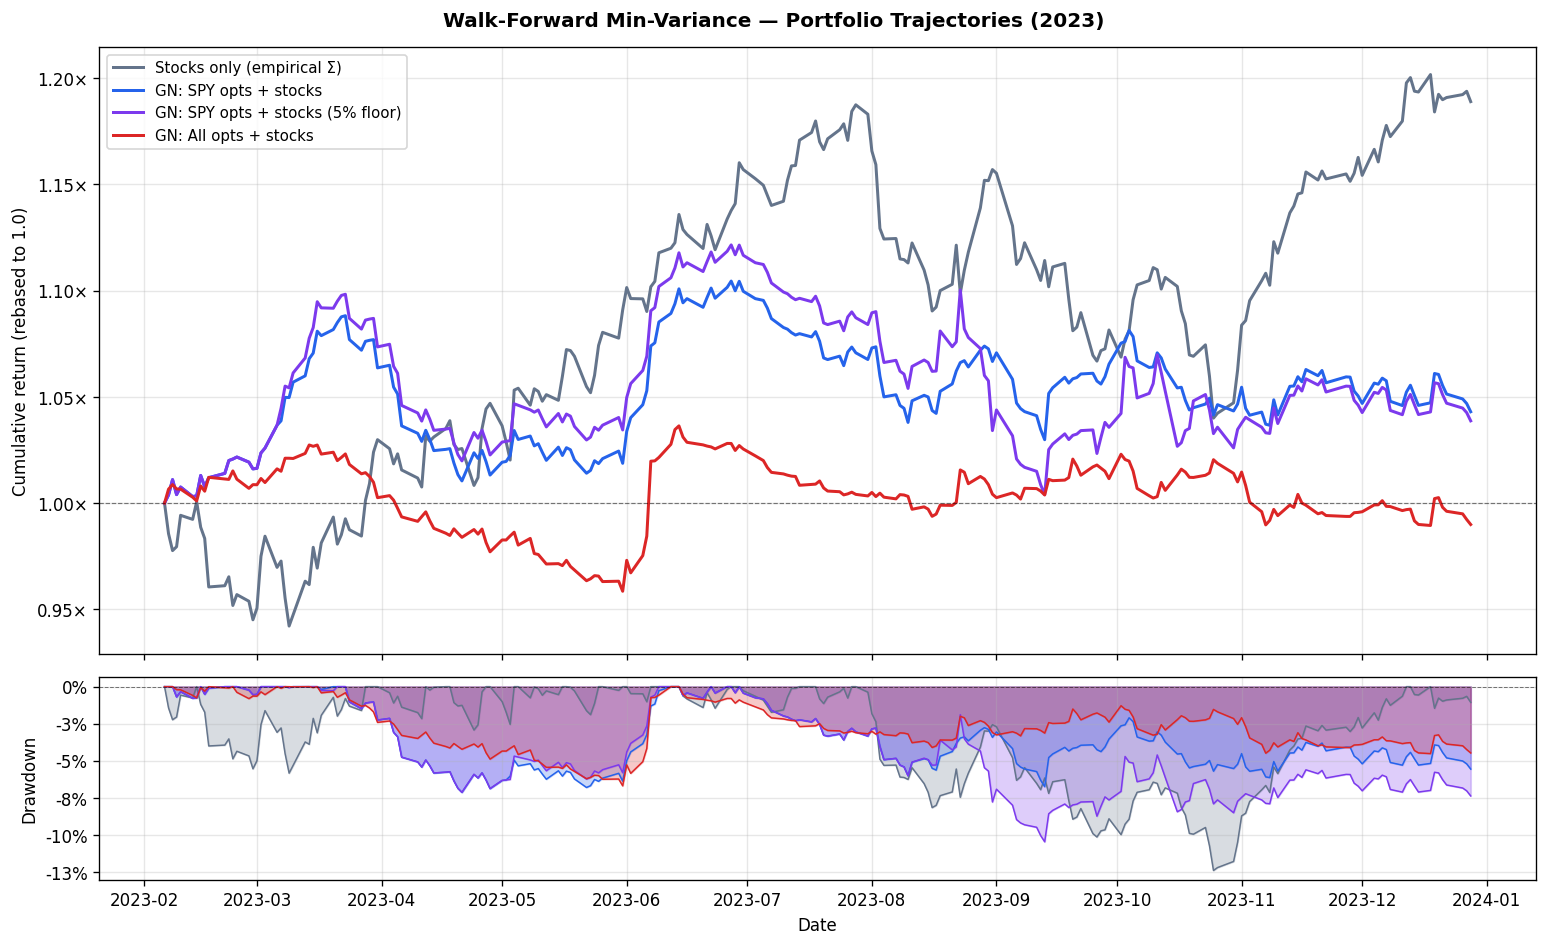

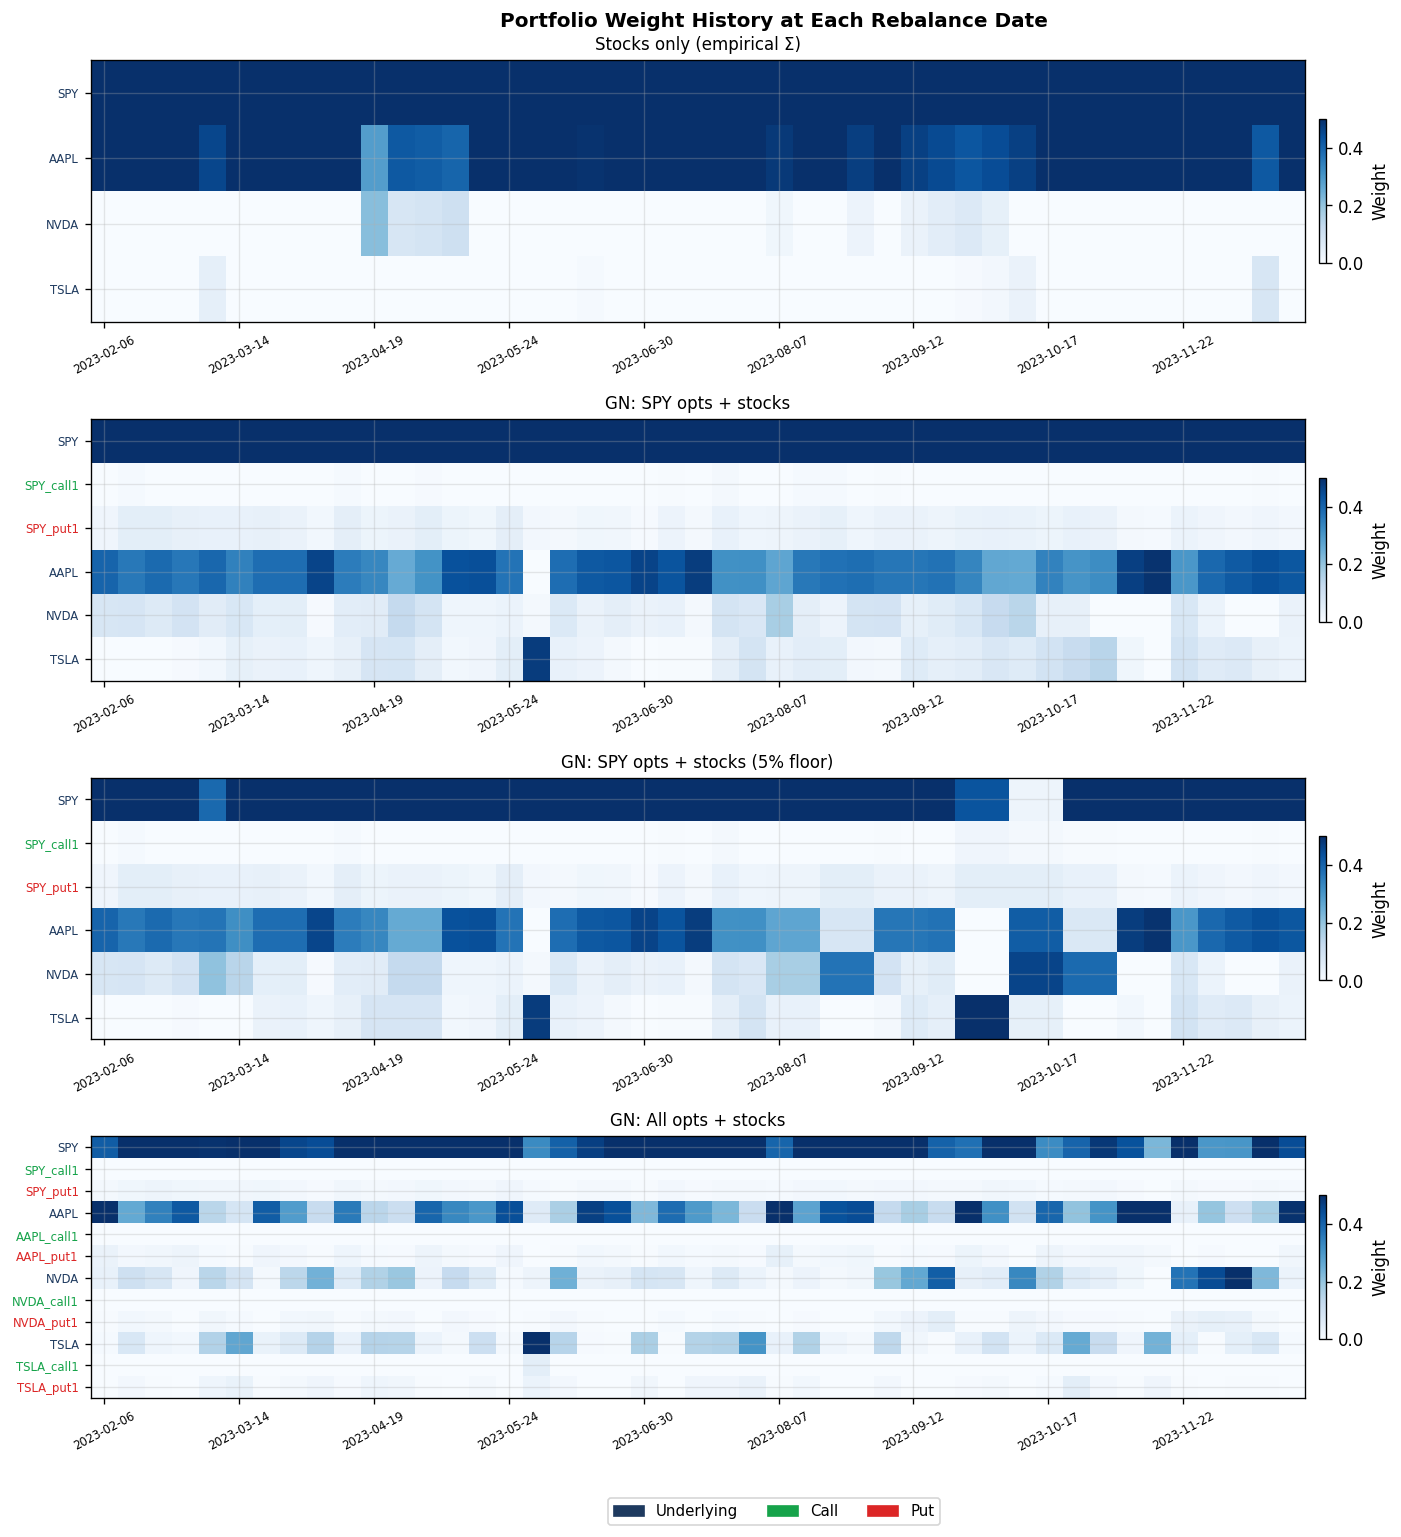

In [23]:
# ── § 5.2  Portfolio trajectories, drawdown, and weight history ─────────────
import matplotlib.ticker as _mtick
import matplotlib.gridspec as _mgs

# Collect all four portfolios ── guard for experiments that may not have run
_all_exps = []
for _path, _wdf, _lbl, _univ in [
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[0], globals().get("_wts0",  pd.DataFrame()), "Stocks only (empirical Σ)",       globals().get("_UNIV_STOCKS", [])),
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[1], globals().get("_wtsA",  pd.DataFrame()), "GN: SPY opts + stocks",            globals().get("_UNIV_A",      [])),
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[2], globals().get("_wtsAp", pd.DataFrame()), "GN: SPY opts + stocks (5% floor)", globals().get("_UNIV_A",      [])),
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[3], globals().get("_wtsB",  pd.DataFrame()), "GN: All opts + stocks",            globals().get("_UNIV_B",      [])),
]:
    if not isinstance(_path, pd.Series) or _path.empty:
        continue
    _all_exps.append((_path, _wdf, _lbl, _univ))

_PAL = ["#64748b", "#2563eb", "#7c3aed", "#dc2626"][:len(_all_exps)]

# ══════════════════════════════════════════════════════════════════════
#  Figure 1: Cumulative returns + rolling drawdown
# ══════════════════════════════════════════════════════════════════════
_fig1, (_ax_traj, _ax_dd) = plt.subplots(
    2, 1, figsize=(13, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)
_fig1.suptitle("Walk-Forward Min-Variance — Portfolio Trajectories (2023)",
               fontsize=12, fontweight="bold")

for (_path, _, _lbl, _), _col in zip(_all_exps, _PAL):
    _reb = _path / _path.iloc[0]
    _ax_traj.plot(_reb.index, _reb.values, label=_lbl, color=_col, lw=1.8)
    _dd = (_reb / _reb.cummax()) - 1
    _ax_dd.fill_between(_dd.index, _dd.values, 0, color=_col, alpha=0.25)
    _ax_dd.plot(_dd.index, _dd.values, color=_col, lw=0.9)

_ax_traj.axhline(1.0, color="k", lw=0.7, ls="--", alpha=0.5)
_ax_traj.set_ylabel("Cumulative return (rebased to 1.0)")
_ax_traj.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f"{y:.2f}×"))
_ax_traj.legend(fontsize=9, loc="upper left")
_ax_traj.grid(axis="y", alpha=0.3)

_ax_dd.axhline(0, color="k", lw=0.6, ls="--", alpha=0.5)
_ax_dd.set_ylabel("Drawdown")
_ax_dd.set_xlabel("Date")
_ax_dd.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f"{y:.0%}"))
_ax_dd.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
#  Figure 2: Weight history — one heatmap row per experiment
# ══════════════════════════════════════════════════════════════════════
_n_exp = len(_all_exps)
_fig2, _axs2 = plt.subplots(_n_exp, 1, figsize=(13, 3.2 * _n_exp), squeeze=False)
_fig2.suptitle("Portfolio Weight History at Each Rebalance Date",
               fontsize=12, fontweight="bold")

for _ax_row, (_path, _wdf, _lbl, _univ) in zip(_axs2[:, 0], _all_exps):
    if _wdf.empty:
        _ax_row.text(0.5, 0.5, "No weight history", ha="center", va="center",
                     transform=_ax_row.transAxes)
        _ax_row.set_title(_lbl, fontsize=10)
        continue

    _cols_plot = [c for c in _univ if c in _wdf.columns]
    if not _cols_plot:
        _cols_plot = list(_wdf.columns)

    _mat = _wdf[_cols_plot].fillna(0.0).T          # assets × rebalance-dates
    _im  = _ax_row.imshow(_mat.values, aspect="auto", vmin=0.0, vmax=0.5,
                           cmap="Blues", interpolation="nearest")

    # y-axis: asset names, colour-coded
    _ax_row.set_yticks(range(len(_cols_plot)))
    _yt_colors = []
    for _c in _cols_plot:
        if "_call" in _c:   _yt_colors.append("#16a34a")
        elif "_put" in _c:  _yt_colors.append("#dc2626")
        else:               _yt_colors.append("#1e3a5f")
    _ax_row.set_yticklabels(_cols_plot, fontsize=7)
    for _tick, _tc in zip(_ax_row.get_yticklabels(), _yt_colors):
        _tick.set_color(_tc)

    # x-axis: every ~8th rebalance date label
    _step = max(1, len(_mat.columns) // 8)
    _ax_row.set_xticks(range(0, len(_mat.columns), _step))
    _ax_row.set_xticklabels(
        [str(d)[:10] for d in _mat.columns[::_step]],
        rotation=28, fontsize=7
    )

    _ax_row.set_title(_lbl, fontsize=10)
    _fig2.colorbar(_im, ax=_ax_row, shrink=0.55, pad=0.01, label="Weight")

# Shared legend for asset-type colour coding
from matplotlib.patches import Patch as _Patch
_fig2.legend(
    handles=[_Patch(color="#1e3a5f", label="Underlying"),
             _Patch(color="#16a34a", label="Call"),
             _Patch(color="#dc2626", label="Put")],
    loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


## 5.3  Diagnosis: Why Results Diverge — and How We Fix Them

### Root Cause 1 — Wrong Timescale in Covariance

The original terminal-payoff Monte Carlo divided by $T \times 252$ **underestimated daily option variance** because ATM options have large **return-space delta leverage** ($\Delta S / C \sim 30\text{--}50\times$ for SPY in this panel).  The “60-window” comparison in `options_free_history.ipynb` that showed huge **realized** vs **predicted** numbers was for **terminal payoffs** (hold to expiry), not for **daily mark-to-market** returns.

**Fix:** Delta–Gamma–Vega (DGV) daily covariance using panel Greeks + GN-fitted $\sigma$.

### Root Cause 2 — SPY opts “won” with tiny option weights

When option weights average only a few percent, the portfolio is still **stock-dominated**; any outperformance is mostly **which stocks** the min-var solution overweighted in 2023, not options “alpha.”

### Root Cause 3 — Put drag in a bull year

Long puts have **negative expected return** when the market trends up.  Without a per-leg cap, the optimizer can still allocate several percent to puts because they look “low vol” in $\Sigma$.

**Fix:** `max_opt_wt = 0.05` (5% cap per option line).

### Data window — options + Greeks

High-quality **same-day options and Greeks** in this repo are in the **2023 research panel** only.  Longer equity histories without a matching options panel would be **stale for this experiment** (no reliable $\Delta,\Gamma,\mathcal{V}$ for DGV).  §5 therefore stays on the **single-year panel**; extending the *calendar* without extending *options quality* is misleading.

### Larger asset universes

`_build_full_cov` scales as **one $3 \times 3$ DGV block per symbol** (underlying + call1 + put1) plus **structural cross-blocks** from rolling underlying correlations and return-space loadings.  Adding symbols is **linear in the number of names** *as long as* each name has a panel row with mids + Greeks at each rebalance.  If you add names **without** panel coverage, those assets cannot enter the GN/DGV path.  Residual risks: **noisy $\rho$** with short lookbacks (use longer `lookback` or shrinkage), and **ill-conditioned** $\Sigma$ when many option legs are near-redundant — the Tikhonov ridge (`$10^{-7} I$`) helps but does not fix bad data.



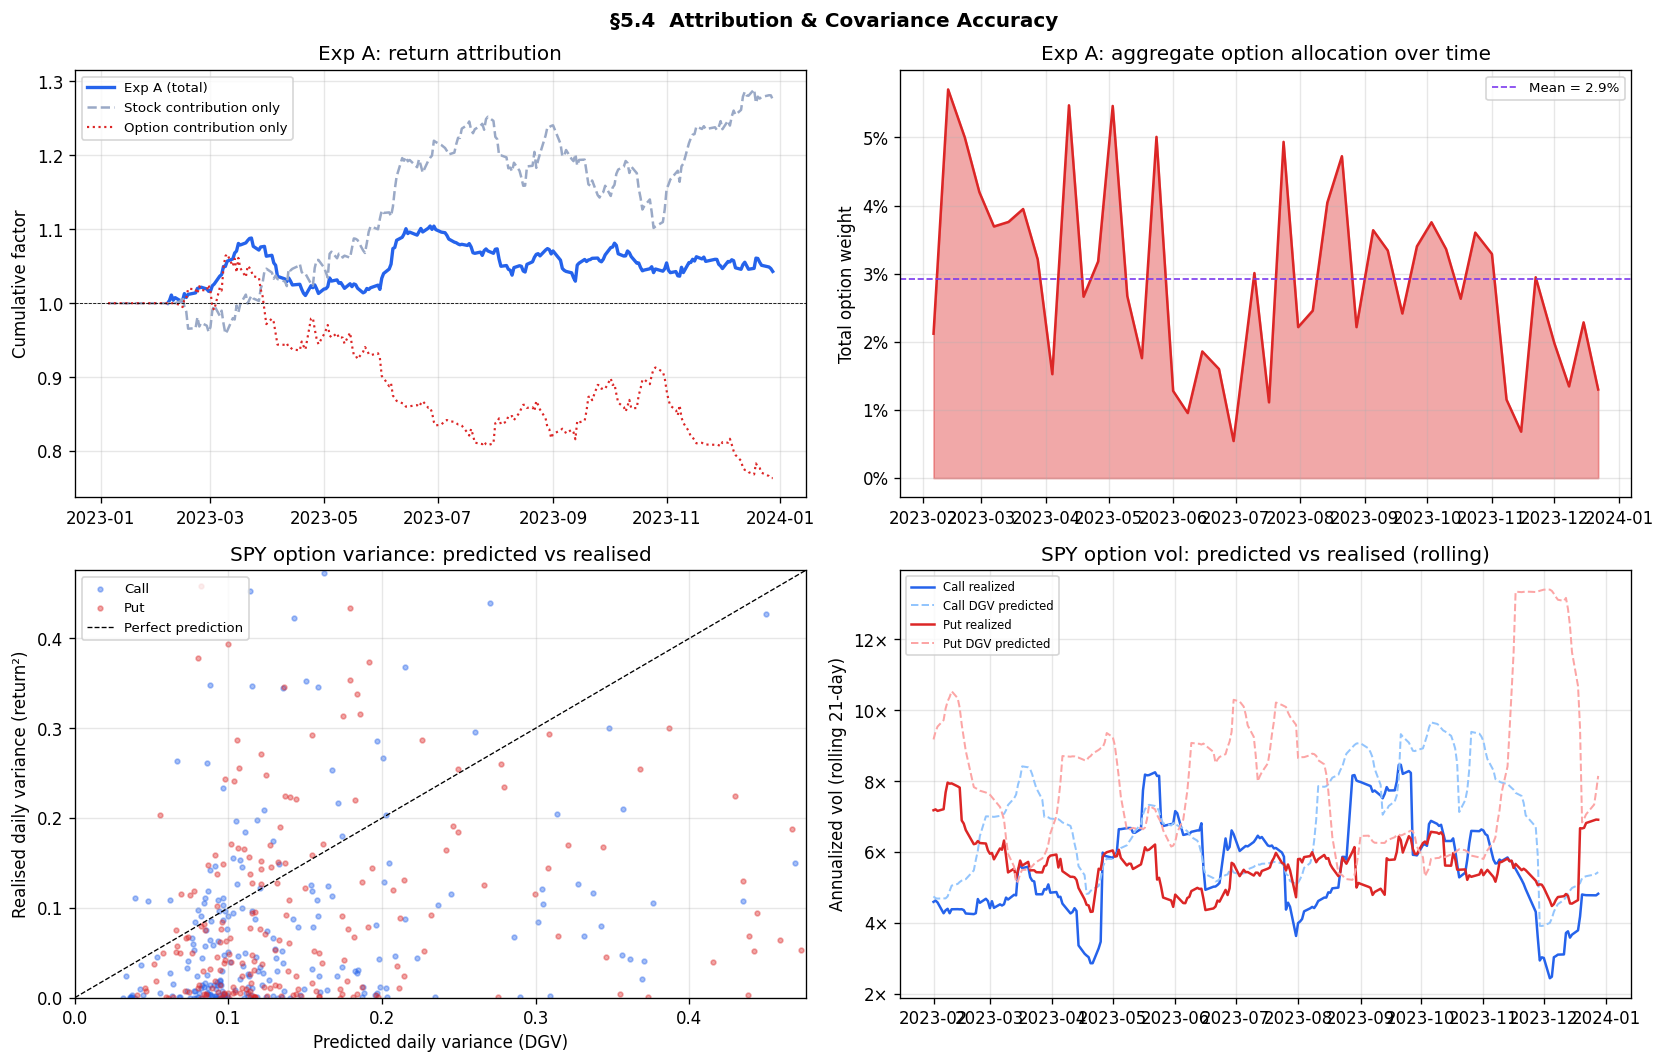


── DGV covariance accuracy (SPY, 2023) ────────────────────────────
  Call var: mean predicted=0.18280  realized=0.12698  ratio=1.44x  rank-corr=0.294
  Put  var: mean predicted=0.27833  realized=0.13521  ratio=2.06x  rank-corr=0.130

── Exp A return attribution ─────────────────────────────────────────
  Stock contribution: 25.40%  (-6268% of total P&L)
  Option contribution: -25.81%  (6368% of total P&L)
  Avg total option weight: 2.9%


In [24]:
# ── §5.4  Attribution: stock vs option contribution + variance accuracy ────────
# Requires cells 37 to have run successfully.

_paths_needed  = globals().get("_paths", [])
_wtsA_chk      = globals().get("_wtsA",  pd.DataFrame())
_rets_all_chk  = globals().get("_rets_all", pd.DataFrame())

if len(_paths_needed) < 2 or _wtsA_chk.empty or _rets_all_chk.empty:
    print("⚠  Run cell 37 first to populate portfolio paths and weights.")
else:
    # ── Panel A: Return attribution Exp A (stock vs option contribution) ─────
    _wtsA_fwd  = _wtsA_chk.shift(1).reindex(_rets_all_chk.index, method="ffill")
    _opt_cols  = [c for c in _UNIV_A if "_call" in c or "_put" in c]
    _und_cols  = [c for c in _UNIV_A if c in _SYMS]

    _r_stocks  = (_wtsA_fwd[_und_cols].fillna(0) * _rets_all_chk[_und_cols]).sum(axis=1)
    _r_opts    = (_wtsA_fwd[_opt_cols].fillna(0) * _rets_all_chk[_opt_cols].fillna(0)).sum(axis=1)

    _cum_stk   = (1 + _r_stocks.dropna()).cumprod()
    _cum_opt   = (1 + _r_opts.dropna()).cumprod()
    _cum_total = _paths_needed[1]   # Exp A path

    fig_attr, axes_attr = plt.subplots(2, 2, figsize=(14, 9))
    fig_attr.suptitle("§5.4  Attribution & Covariance Accuracy", fontsize=12, fontweight="bold")

    # A1: Cumulative attribution
    ax = axes_attr[0, 0]
    ax.plot(_cum_total.index, _cum_total.values / _cum_total.iloc[0],
            color="#2563eb", lw=2.0, label="Exp A (total)")
    ax.plot(_cum_stk.index,   _cum_stk.values   / _cum_stk.iloc[0],
            color="#9aa9c6", lw=1.5, ls="--", label="Stock contribution only")
    ax.plot(_cum_opt.index,   _cum_opt.values   / _cum_opt.iloc[0],
            color="#dc2626", lw=1.3, ls=":", label="Option contribution only")
    ax.axhline(1, color="k", lw=0.5, ls="--")
    ax.set_title("Exp A: return attribution")
    ax.legend(fontsize=8)
    ax.set_ylabel("Cumulative factor")

    # A2: Option weight over time
    ax = axes_attr[0, 1]
    if not _wtsA_chk.empty:
        total_opt_wt = _wtsA_chk[_opt_cols].sum(axis=1)
        ax.fill_between(total_opt_wt.index, total_opt_wt.values, alpha=0.4, color="#dc2626")
        ax.plot(total_opt_wt.index, total_opt_wt.values, color="#dc2626", lw=1.5)
        ax.axhline(total_opt_wt.mean(), color="#7c3aed", lw=1.0, ls="--",
                   label=f"Mean = {total_opt_wt.mean():.1%}")
        ax.set_ylabel("Total option weight")
        ax.set_title("Exp A: aggregate option allocation over time")
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f"{y:.0%}"))

    # A3: Predicted vs realized daily variance (SPY call + put)
    ax = axes_attr[1, 0]
    _rp_spy = _rp[_rp["symbol"] == "SPY"].copy()
    _rp_spy["date_t"] = pd.to_datetime(_rp_spy["date_t"])

    _pred_var_c, _real_var_c = [], []
    _pred_var_p, _real_var_p = [], []
    _dates_var = []

    _rng_diag = np.random.default_rng(0)
    for _, _row in _rp_spy.iterrows():
        _gn_r = _gn_cov_dgv(_row.to_dict(), rng=_rng_diag)
        if _gn_r is None:
            continue
        _pred_var_c.append(float(_gn_r["Sigma_daily"][1, 1]))
        _pred_var_p.append(float(_gn_r["Sigma_daily"][2, 2]))
        _real_var_c.append(float(_row["call_1_R_real"])**2)
        _real_var_p.append(float(_row["put_1_R_real"])**2)
        _dates_var.append(pd.to_datetime(_row["date_t"]))

    _pred_vc = pd.Series(_pred_var_c, index=_dates_var)
    _real_vc = pd.Series(_real_var_c, index=_dates_var)
    _pred_vp = pd.Series(_pred_var_p, index=_dates_var)
    _real_vp = pd.Series(_real_var_p, index=_dates_var)

    ax.scatter(_pred_vc.values, _real_vc.values, s=8, alpha=0.4,
               color="#2563eb", label="Call")
    ax.scatter(_pred_vp.values, _real_vp.values, s=8, alpha=0.4,
               color="#dc2626", label="Put")
    _lim = max(np.percentile(_real_vc.values, 95),
               np.percentile(_real_vp.values, 95))
    ax.plot([0, _lim], [0, _lim], "k--", lw=0.8, label="Perfect prediction")
    ax.set_xlim(0, _lim); ax.set_ylim(0, _lim)
    ax.set_xlabel("Predicted daily variance (DGV)")
    ax.set_ylabel("Realised daily variance (return²)")
    ax.set_title("SPY option variance: predicted vs realised")
    ax.legend(fontsize=8)

    # A4: Rolling 30-day vol — predicted vs realized
    ax = axes_attr[1, 1]
    _pred_vol_c = _pred_vc.rolling(21).mean().apply(np.sqrt) * np.sqrt(252)
    _real_vol_c = _real_vc.rolling(21).mean().apply(np.sqrt) * np.sqrt(252)
    _pred_vol_p = _pred_vp.rolling(21).mean().apply(np.sqrt) * np.sqrt(252)
    _real_vol_p = _real_vp.rolling(21).mean().apply(np.sqrt) * np.sqrt(252)

    ax.plot(_real_vol_c.index, _real_vol_c.values, color="#2563eb", lw=1.5, label="Call realized")
    ax.plot(_pred_vol_c.index, _pred_vol_c.values, color="#93c5fd", lw=1.2, ls="--",
            label="Call DGV predicted")
    ax.plot(_real_vol_p.index, _real_vol_p.values, color="#dc2626", lw=1.5, label="Put realized")
    ax.plot(_pred_vol_p.index, _pred_vol_p.values, color="#fca5a5", lw=1.2, ls="--",
            label="Put DGV predicted")
    ax.set_ylabel("Annualized vol (rolling 21-day)")
    ax.set_title("SPY option vol: predicted vs realised (rolling)")
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f"{y:.0f}×"))

    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────────
    _corr_c = float(pd.Series(_pred_var_c).corr(pd.Series(_real_var_c)))
    _corr_p = float(pd.Series(_pred_var_p).corr(pd.Series(_real_var_p)))
    print(f"\n── DGV covariance accuracy (SPY, 2023) ────────────────────────────")
    print(f"  Call var: mean predicted={np.mean(_pred_var_c):.5f}  realized={np.mean(_real_var_c):.5f}  "
          f"ratio={np.mean(_pred_var_c)/np.mean(_real_var_c):.2f}x  rank-corr={_corr_c:.3f}")
    print(f"  Put  var: mean predicted={np.mean(_pred_var_p):.5f}  realized={np.mean(_real_var_p):.5f}  "
          f"ratio={np.mean(_pred_var_p)/np.mean(_real_var_p):.2f}x  rank-corr={_corr_p:.3f}")

    stock_pct = _r_stocks.sum() / (_r_stocks.sum() + _r_opts.sum() + 1e-9)
    print(f"\n── Exp A return attribution ─────────────────────────────────────────")
    print(f"  Stock contribution: {_r_stocks.sum():.2%}  ({stock_pct:.0%} of total P&L)")
    print(f"  Option contribution: {_r_opts.sum():.2%}  ({1-stock_pct:.0%} of total P&L)")
    print(f"  Avg total option weight: {_wtsA_chk[_opt_cols].sum(axis=1).mean():.1%}")


## 5.5  Efficient Frontier Ablation

### Is Terminal GN Still Used?

**Yes — in its original role.**  The Gauss-Newton / DNLP calibration is still
the *first step* of every DGV covariance estimate:

| Step | What GN provides | Use |
|:---|:---|:---|
| **Still used** — Option calibration | GN fits $(\hat\mu, \hat\sigma)$ to 4 market mids each rebalance | Forward-looking $\bar\sigma$ averaged over Fisher-sampled draws |
| **Still used** — Distribution viz | §2–§3 terminal distribution $S_T \sim \text{LogNormal}(\ldots)$ | Illustrates fitted density vs market IV baseline |
| **Replaced** — Covariance input | Old: simulate terminal payoffs, divide by $T \cdot 252$ | New: **Delta–Gamma–Vega** formula using same $\bar\sigma$ + panel Greeks |

The terminal-price MC was *not* removed from the notebook; it still lives in
§2–§3.  Only the portfolio-covariance construction switched from terminal
simulation to DGV.  If you wanted to restore terminal MC for covariance (e.g.,
to capture deep-OTM tail risk not captured by Greeks), you could run it as an
*additional* block alongside DGV and compare — it would be a natural next
ablation.

---

### Efficient Frontier Ablation — Setup

At a single snapshot date (late-2023), build DGV $\Sigma$ and expected-return
vector $\mu$ for each universe, then trace the feasible frontier.

**Expected return sources:**

| Asset | $\mu$ estimate |
|:---|:---|
| Underlying ($s$) | Rolling 63-day historical mean return (annualised) |
| Call option | $\ell_c \cdot \bar\mu_\text{und}$  where $\ell_c = \Delta_c S_0/C_0$ (delta approx) |
| Put option  | $\ell_p \cdot \bar\mu_\text{und}$  where $\ell_p = \Delta_p S_0/P_0$ (negative leverage) |

> **Caveat:** delta-approx $\mu_\text{option}$ uses a *physical*-measure underlying
> drift, not a risk-neutral one.  It amplifies estimation noise by the leverage
> factor.  In practice you'd also include an IV-premium or a separate model.

**Ablation objectives compared on the frontier:**

| Label | Objective | Constraint extras |
|:---|:---|:---|
| Min-Var | $\min w^\top\Sigma w$ | — |
| Min-Var + 5 % floor | $\min w^\top\Sigma w$ | $\mu^\top w \geq 5\%$ |
| MV $\gamma=1$ | $\max (\mu-r_f)^\top w - w^\top\Sigma w$ | — |
| MV $\gamma=5$ | $\max (\mu-r_f)^\top w - 5 w^\top\Sigma w$ | — |
| Max-Sharpe* | Point on frontier with highest $(\mu^\top w - r_f)/\sigma_w$ | — |
| Equal-Weight | $w_i = 1/n$ | Fixed (not optimised) |

*(Max-Sharpe found by scanning the traced frontier)


Building DGV Σ + μ for all universes at 2023-11-30 …
  Stocks only: 4 assets  μ_und=[3.0%, 10.1%, -21.7%, 3.5%]
  SPY opts + stocks: 6 assets  μ_und=[3.0%, 10.1%, -21.7%, 3.5%]
  All opts + stocks: 12 assets  μ_und=[3.0%, 10.1%, -21.7%, 3.5%]

Tracing frontiers …
  Stocks only: 55 points  vol=[12.5%–17.9%]  ret=[6.5%–6.6%]
  SPY opts + stocks: 55 points  vol=[5.6%–34.7%]  ret=[2.0%–12.4%]
  All opts + stocks: 55 points  vol=[1.2%–54.6%]  ret=[0.1%–40.1%]


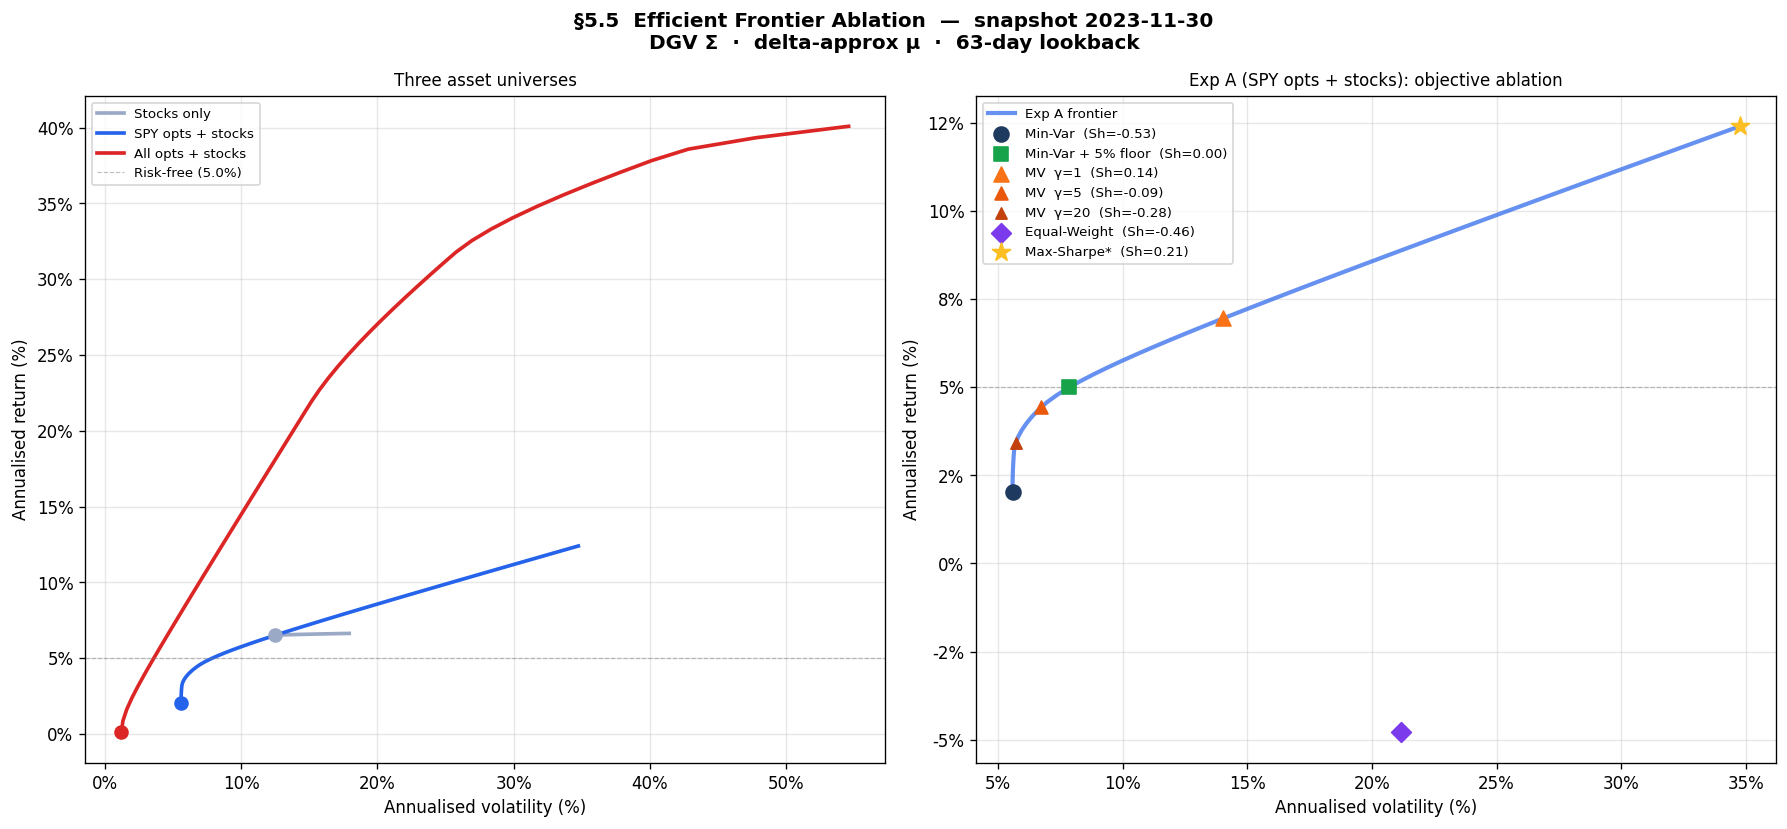


── Ablation: Exp A (SPY opts + stocks)  ─────────────────────────────────
  Objective               Ann Return   Ann Vol   Sharpe
  ------------------------------------------------------
  Min-Var                      2.0%     5.6%    -0.53
  Min-Var + 5% floor           5.0%     7.9%     0.00
  MV  γ=1                      7.0%    14.0%     0.14
  MV  γ=5                      4.4%     6.7%    -0.09
  MV  γ=20                     3.4%     5.7%    -0.28
  Equal-Weight                -4.8%    21.2%    -0.46
  Max-Sharpe*                 12.4%    34.7%     0.21

── Top avg weights per ablation (Exp A universe) ─────────────────────────
  Min-Var               : SPY=0.50  AAPL=0.40  TSLA=0.05  NVDA=0.03  SPY_put1=0.02
  Min-Var + 5% floor    : AAPL=0.50  SPY=0.49  SPY_put1=0.01
  MV  γ=1               : AAPL=0.50  SPY=0.50
  MV  γ=5               : AAPL=0.50  SPY=0.49  SPY_put1=0.01
  MV  γ=20              : SPY=0.50  AAPL=0.45  TSLA=0.04  SPY_put1=0.02
  Equal-Weight          : SPY=0.17 

In [25]:
# ── §5.5  Efficient Frontier Ablation ────────────────────────────────────────
# Requires: cells 35–36 (panel + DGV engine). Runs standalone from cell 37.

_SNAP_DATE = pd.Timestamp("2023-11-30")   # snapshot for one-period frontier
_LB_EF     = 63                           # rolling lookback for μ and ρ

# ── 1. Build annualised Sigma + mu at snapshot ────────────────────────────────
def _ef_sigma_mu(univ, syms, rp_idx, rets_df, snap=_SNAP_DATE, lb=_LB_EF):
    cols = [c for c in univ if c in rets_df.columns]
    try:
        Sig_d, gn = _build_full_cov(snap, rp_idx, rets_df[syms], syms, cols, lb)
    except Exception as e:
        print(f"  DGV error for {snap}: {e}"); return None
    Sig = Sig_d * 252   # daily → annualised

    end_l   = rets_df.index.get_indexer([snap], method="ffill")[0]
    start_l = max(0, end_l - lb)
    win     = rets_df.iloc[start_l:end_l]

    mu = np.zeros(len(cols))
    for k, c in enumerate(cols):
        sym = c.split("_")[0]
        if c in syms:                          # underlying: rolling historical
            h = win[c].dropna()
            mu[k] = float(h.mean()) * 252 if len(h) >= 5 else 0.0
        elif sym in gn:                        # option: delta-approx μ
            lev = gn[sym]["lev_c"] if "_call" in c else gn[sym]["lev_p"]
            h   = win[sym].dropna()
            mu_und = float(h.mean()) * 252 if len(h) >= 5 else 0.0
            mu[k] = lev * mu_und              # amplified by return-space leverage
    return cols, mu, Sig


# ── 2. Solve a single portfolio optimisation ──────────────────────────────────
def _solve_one(cols, mu, Sig, target_ret=None, gamma=None,
               max_wt=0.5, max_opt_wt=0.05, rf=R_ANN):
    n    = len(cols)
    w    = cp.Variable(n, nonneg=True)
    base = [cp.sum(w) == 1, w <= max_wt] + \
           [w[k] <= max_opt_wt
            for k, c in enumerate(cols) if "_call" in c or "_put" in c]

    if gamma is not None:
        prob = cp.Problem(cp.Maximize((mu - rf) @ w - gamma * cp.quad_form(w, Sig)), base)
    elif target_ret is not None:
        prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sig)),
                          base + [mu @ w >= target_ret])
    else:
        prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sig)), base)

    prob.solve(solver=cp.CLARABEL, warm_start=True)
    if w.value is None:
        prob.solve(solver=cp.SCS)
    if w.value is None:
        return None, None, None
    wv = np.clip(np.asarray(w.value).flatten(), 0, 1)
    wv /= wv.sum()
    vol = float(np.sqrt(wv @ Sig @ wv))
    ret = float(mu @ wv)
    return wv, ret, vol


# ── 3. Trace efficient frontier ───────────────────────────────────────────────
def _trace_ef(cols, mu, Sig, n_pts=55, max_wt=0.5, max_opt_wt=0.05):
    _, ret_mv, vol_mv = _solve_one(cols, mu, Sig, max_wt=max_wt, max_opt_wt=max_opt_wt)
    if ret_mv is None:
        return [], []
    # Max-return feasible upper bound
    n = len(cols); w = cp.Variable(n, nonneg=True)
    base = [cp.sum(w)==1, w<=max_wt] + [w[k]<=max_opt_wt
             for k,c in enumerate(cols) if "_call" in c or "_put" in c]
    pb = cp.Problem(cp.Maximize(mu @ w), base); pb.solve(solver=cp.CLARABEL)
    ret_max = float(mu @ np.clip(w.value,0,1)) if w.value is not None else float(mu.max())

    vols_ef, rets_ef = [vol_mv], [ret_mv]
    for tgt in np.linspace(ret_mv, ret_max * 0.98, n_pts - 1):
        _, r, v = _solve_one(cols, mu, Sig, target_ret=tgt,
                             max_wt=max_wt, max_opt_wt=max_opt_wt)
        if r is not None:
            vols_ef.append(v); rets_ef.append(r)
    return vols_ef, rets_ef


# ── 4. Build all three universes ──────────────────────────────────────────────
print("Building DGV Σ + μ for all universes at", _SNAP_DATE.date(), "…")
_ef_data = {}
for _univ_key, _univ in [("Stocks only", _UNIV_STOCKS),
                          ("SPY opts + stocks", _UNIV_A),
                          ("All opts + stocks", _UNIV_B)]:
    _res = _ef_sigma_mu(_univ, _SYMS, _rp_idx, _rets_all)
    if _res is None:
        print(f"  Skipping {_univ_key}")
        continue
    _ef_data[_univ_key] = _res
    print(f"  {_univ_key}: {len(_res[0])} assets  "
          f"μ_und=[{', '.join(f'{_res[1][_res[0].index(s)]*100:.1f}%' for s in _SYMS if s in _res[0])}]")

# ── 5. Trace frontiers ────────────────────────────────────────────────────────
print("\nTracing frontiers …")
_ef_curves = {}
for _uk, (_cols, _mu, _Sig) in _ef_data.items():
    _vols, _rets = _trace_ef(_cols, _mu, _Sig)
    _ef_curves[_uk] = (_vols, _rets)
    print(f"  {_uk}: {len(_vols)} points  "
          f"vol=[{min(_vols):.1%}–{max(_vols):.1%}]  "
          f"ret=[{min(_rets):.1%}–{max(_rets):.1%}]")

# ── 6. Ablation portfolios for Exp A universe ─────────────────────────────────
_cols_A, _mu_A, _Sig_A = _ef_data.get("SPY opts + stocks", (None,None,None))
_ablation = {}
if _cols_A is not None:
    _ablation_specs = [
        ("Min-Var",              dict()),
        ("Min-Var + 5% floor",   dict(target_ret=0.05)),
        ("MV  γ=1",              dict(gamma=1.0)),
        ("MV  γ=5",              dict(gamma=5.0)),
        ("MV  γ=20",             dict(gamma=20.0)),
    ]
    for _lbl, _kw in _ablation_specs:
        _wv, _r, _v = _solve_one(_cols_A, _mu_A, _Sig_A, **_kw)
        if _wv is not None:
            _sharpe = (_r - R_ANN) / _v if _v > 0 else np.nan
            _ablation[_lbl] = dict(w=_wv, ret=_r, vol=_v, sharpe=_sharpe)
    # Equal-weight (not optimised)
    _wv_ew = np.ones(len(_cols_A)) / len(_cols_A)
    _r_ew  = float(_mu_A @ _wv_ew)
    _v_ew  = float(np.sqrt(_wv_ew @ _Sig_A @ _wv_ew))
    _ablation["Equal-Weight"] = dict(w=_wv_ew, ret=_r_ew, vol=_v_ew,
                                      sharpe=(_r_ew-R_ANN)/_v_ew)
    # Max-Sharpe: scan traced frontier
    _vefs_A, _refs_A = _ef_curves.get("SPY opts + stocks", ([],[]))
    if _vefs_A:
        _sharpes_ef = [(r - R_ANN) / v if v > 0 else -np.inf
                       for r, v in zip(_refs_A, _vefs_A)]
        _i_ms = int(np.argmax(_sharpes_ef))
        _, _r_ms, _v_ms = _solve_one(_cols_A, _mu_A, _Sig_A,
                                      target_ret=_refs_A[_i_ms])
        if _r_ms is not None:
            _ablation["Max-Sharpe*"] = dict(w=None, ret=_r_ms, vol=_v_ms,
                                             sharpe=(_r_ms-R_ANN)/_v_ms)

# ── 7. Plot ───────────────────────────────────────────────────────────────────
import matplotlib.ticker as _mt

_CURVE_COL = {"Stocks only": "#9aa9c6",
              "SPY opts + stocks": "#2563eb",
              "All opts + stocks": "#dc2626"}
_ABL_MARKERS = {
    "Min-Var":           ("o",  "#1e3a5f", 80),
    "Min-Var + 5% floor":("s",  "#16a34a", 80),
    "MV  γ=1":           ("^",  "#f97316", 80),
    "MV  γ=5":           ("^",  "#ea580c", 60),
    "MV  γ=20":          ("^",  "#c2410c", 45),
    "Max-Sharpe*":       ("*",  "#fbbf24", 130),
    "Equal-Weight":      ("D",  "#7c3aed", 70),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("§5.5  Efficient Frontier Ablation  —  snapshot 2023-11-30\n"
             "DGV Σ  ·  delta-approx μ  ·  63-day lookback",
             fontsize=12, fontweight="bold")

# Left: all three frontiers
ax = axes[0]
for _uk, (_vols, _rets) in _ef_curves.items():
    if not _vols: continue
    ax.plot([v*100 for v in _vols], [r*100 for r in _rets],
            lw=2.2, color=_CURVE_COL[_uk], label=_uk)
    ax.scatter([_vols[0]*100], [_rets[0]*100],   # mark min-var
               s=60, color=_CURVE_COL[_uk], zorder=5, marker="o")
ax.axhline(R_ANN*100, color="gray", lw=0.7, ls="--", alpha=0.5, label=f"Risk-free ({R_ANN:.1%})")
ax.set_xlabel("Annualised volatility (%)")
ax.set_ylabel("Annualised return (%)")
ax.set_title("Three asset universes", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(_mt.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(_mt.FuncFormatter(lambda y,_: f"{y:.0f}%"))

# Right: Exp A frontier + ablation points
ax = axes[1]
_vef_A, _ref_A = _ef_curves.get("SPY opts + stocks", ([],[]))
if _vef_A:
    ax.plot([v*100 for v in _vef_A], [r*100 for r in _ref_A],
            lw=2.5, color="#2563eb", alpha=0.7, label="Exp A frontier")
for _lbl, _d in _ablation.items():
    _mk, _c, _sz = _ABL_MARKERS.get(_lbl, ("o","gray",60))
    ax.scatter([_d["vol"]*100], [_d["ret"]*100],
               marker=_mk, color=_c, s=_sz, zorder=6,
               label=f"{_lbl}  (Sh={_d['sharpe']:.2f})")
ax.axhline(R_ANN*100, color="gray", lw=0.7, ls="--", alpha=0.5)
ax.set_xlabel("Annualised volatility (%)")
ax.set_ylabel("Annualised return (%)")
ax.set_title("Exp A (SPY opts + stocks): objective ablation", fontsize=10)
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(_mt.FuncFormatter(lambda x,_: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(_mt.FuncFormatter(lambda y,_: f"{y:.0f}%"))

plt.tight_layout()
plt.show()

# ── 8. Summary table ──────────────────────────────────────────────────────────
print("\n── Ablation: Exp A (SPY opts + stocks)  ─────────────────────────────────")
print(f"  {'Objective':<22s}  {'Ann Return':>10s}  {'Ann Vol':>8s}  {'Sharpe':>7s}")
print("  " + "-"*54)
for _lbl, _d in _ablation.items():
    print(f"  {_lbl:<22s}  {_d['ret']:>9.1%}  {_d['vol']:>7.1%}  {_d['sharpe']:>7.2f}")

if _cols_A is not None:
    print("\n── Top avg weights per ablation (Exp A universe) ─────────────────────────")
    for _lbl, _d in _ablation.items():
        if _d.get("w") is None: continue
        top = sorted(zip(_cols_A, _d["w"]), key=lambda x: -x[1])[:5]
        print(f"  {_lbl:<22s}: " + "  ".join(f"{c}={v:.2f}" for c,v in top if v>0.01))
